# 007. 学習の安定化(Training Stabilization)


## 1. 概要 / Overview

006(小型 GPT の事前学習)は、Adam(固定学習率、gradient clipping なし)という意図的に素朴な学習設定を採用し、実験 H でその限界を観測しようとした。しかしスモークテストのごく短い学習では明確な不安定化を引き出せず、「素朴な学習設定がどこで壊れるか」は未検証のまま残った。007 では、**正規化前置(Pre-Layer Normalization)/ 正規化後置(Post-Layer Normalization、002)と学習率を独立変数として意図的に不安定性を誘発し**、AdamW(Decoupled Weight Decay Regularization)・warmup + cosine スケジュール・gradient clipping(勾配クリッピング)という 3 つの安定化技術それぞれが、どの種類の不安定性に効くかを切り分けて検証する。mixed precision(混合精度学習)は数値精度(FP16 / BF16 の underflow/overflow)に起因する別種の問題であり、011(混合精度学習)に切り出す。


## 2. 参考論文 / References

| # | 著者 / Authors | タイトル / Title | 会議・媒体 / Venue | URL |
|---|---|---|---|---|
| [1] | Loshchilov, I., Hutter, F. | Decoupled Weight Decay Regularization | ICLR 2019 | https://arxiv.org/abs/1711.05101 |
| [2] | Kingma, D. P., Ba, J. | Adam: A Method for Stochastic Optimization | ICLR 2015 | https://arxiv.org/abs/1412.6980 |
| [3] | Goyal, P., et al. | Accurate, Large Minibatch SGD: Training ImageNet in 1 Hour | 2017 | https://arxiv.org/abs/1706.02677 |
| [4] | Loshchilov, I., Hutter, F. | SGDR: Stochastic Gradient Descent with Warm Restarts | ICLR 2017 | https://arxiv.org/abs/1608.03983 |
| [5] | Brown, T. B., et al. | Language Models are Few-Shot Learners | NeurIPS 2020 | https://arxiv.org/abs/2005.14165 |
| [6] | Pascanu, R., Mikolov, T., Bengio, Y. | On the difficulty of training Recurrent Neural Networks | ICML 2013 | https://arxiv.org/abs/1211.5063 |
| [7] | Xiong, R., et al. | On Layer Normalization in the Transformer Architecture | ICML 2020 | https://arxiv.org/abs/2002.04745 |

本文中で各理論に言及する際は、対応する番号(例:「decoupled weight decay [1]」)を付す。


## 3. 理論 / Theory


### 3.1 動機・課題: なぜ「安定化」を独立トピックとして扱うか

**002 で観測した正規化後置の勾配の不均衡**: [002_transformer_block.ipynb](../01_foundations/002_transformer_block.ipynb) は、正規化前置(Pre-Layer Normalization)と正規化後置(Post-Layer Normalization、Xiong et al. [7])を比較し、正規化後置では残差経路そのものが正規化を経由しない正規化前置と異なり、層を重ねるほど勾配のスケールが不均衡になりやすいことを確認した。

**004 で観測した正規化欠如条件でのシード間ばらつきの増大**: [004_normalization_and_activation.ipynb](../01_foundations/004_normalization_and_activation.ipynb) は、正規化を欠いた条件で学習のシード間ばらつきが増大することを観測した。正規化の有無が、学習の再現性・安定性そのものに影響することを示唆する。

**006 実験 H は不安定性を引き出せなかった**: [006_pretraining_small_gpt.ipynb](./006_pretraining_small_gpt.ipynb) の実験 H は、素朴な学習設定(Adam・固定学習率・gradient clipping なし)での勾配ノルムを記録する仕組みを用意したが、スモークテストの短い学習では明確なスパイクや発散を観測できなかった(006 7.4 節)。これは「安定化技術が不要である」ことを意味しない。**むしろ、不安定性が生じる条件そのものを意図的に作り出さなければ、安定化技術の効果を検証しようがない**、というのが 007 の出発点である。

**007 の設計方針**: 正規化前置 / 正規化後置(アーキテクチャ)と学習率(ハイパーパラメータ)を独立変数として直交させ、意図的に不安定性を誘発する条件(正規化後置 × 高学習率)を作った上で、AdamW・warmup + cosine スケジュール・gradient clipping のそれぞれがこの不安定性に効くかを個別に検証する(3.5 節・7 節)。


### 3.2 AdamW(Decoupled Weight Decay Regularization)

**記号 / Notation**:

- $\theta$: パラメータ
- $g_t$: ステップ $t$ の勾配($\partial \mathcal{L} / \partial \theta$)
- $\eta$: 学習率(learning rate)
- $\beta_1, \beta_2$: モーメント推定の指数移動平均の減衰率
- $m_t, v_t$: 1 次・2 次モーメント推定
- $\hat{m}_t, \hat{v}_t$: バイアス補正後のモーメント推定
- $\epsilon$: 数値安定化のための微小定数
- $\lambda$: 重み減衰係数(weight decay)

**Adam のモーメント推定 [2]**: Adam は勾配の 1 次モーメント(移動平均、方向)と 2 次モーメント(移動平均、スケール)を推定し、パラメータごとに更新幅を正規化する。

$$
m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t, \qquad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2
$$

$$
\hat{m}_t = \frac{m_t}{1-\beta_1^t}, \qquad \hat{v}_t = \frac{v_t}{1-\beta_2^t}, \qquad
u_t = \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
$$

$u_t$ は「勾配の典型的なスケールで正規化した更新方向」であり、$\theta \leftarrow \theta - \eta u_t$ がバニラ Adam の更新式である。

**L2 正則化を勾配に混ぜる方式(素朴な重み減衰)**: 重み減衰を実装する素朴な方法は、L2 正則化の勾配 $\lambda \theta$ を通常の勾配に加算することである。

$$
\tilde{g}_t = g_t + \lambda \theta_{t-1}
$$

この $\tilde{g}_t$ を Adam のモーメント推定にそのまま使う(`AdamWithL2Regularization`、`src/training/optimizer.py`)。**この方式には問題がある**: 重み減衰の寄与 $\lambda \theta$ が $\hat{v}_t$(2 次モーメント推定、勾配のスケールを反映)を経由してしまう。勾配 $g_t$ が恒常的に大きいパラメータ群では $\hat{v}_t \approx g_t^2 \gg (\lambda\theta)^2$ となり、重み減衰の寄与は $u_t$ の中でほぼ無視できるほど薄まる。逆に $g_t$ が恒常的に小さいパラメータ群では $\hat{v}_t \approx (\lambda\theta)^2$ となり、重み減衰由来の項が正規化によって $O(1)$ まで増幅される。**同一の名目上の $\lambda$ が、パラメータ群の勾配スケールに応じて全く異なる実効的な減衰強度をもたらしてしまう。**

**Decoupled weight decay(AdamW)[1]**: Loshchilov & Hutter は、重み減衰をモーメント推定(したがって $\hat{v}_t$ による正規化)から完全に切り離し、パラメータ更新式に別項として直接加えることを提案した。

$$
\theta_t = \theta_{t-1} - \eta \left( u_t + \lambda \theta_{t-1} \right)
= \theta_{t-1}(1 - \eta\lambda) - \eta u_t
$$

$u_t$ の計算(1 次・2 次モーメント推定)には $\tilde{g}_t$ ではなく元の勾配 $g_t$ のみを使う。重み減衰の項 $\eta\lambda\theta_{t-1}$ は $\hat{v}_t$ を一切経由しないため、実効的な減衰強度 $\eta\lambda$ はパラメータ群の勾配スケールに依存しない、**設計上の定数** になる。この違いを、勾配スケールが異なる複数のパラメータ群を用意した合成タスクで直接検証する(主張 6、6.8 節)。

**002・004 との関係**: AdamW 自体は不安定性の「スパイク」を直接抑える機構ではない(gradient clipping・warmup とは異なる役割)。むしろ、重み減衰という正則化がパラメータ群間で公平に働くことを保証する技術であり、正規化方式(002)によってパラメータ群間の勾配スケールの不均衡が生じる(3.1 節)ほど、AdamW と L2 正則化混入の実効的な差は大きくなりうる。


### 3.3 warmup + cosine スケジュール

学習率スケジュール(`compute_warmup_cosine_learning_rate`、`src/training/schedule.py`)は、学習序盤に学習率を線形に立ち上げる **warmup**(ステップ数 $w$)と、その後コサイン曲線に沿って減衰させる **cosine decay** を組み合わせる(GPT-3 [5] の Appendix D などで採用される標準的な構成)。

$$
\eta(s) =
\begin{cases}
\eta_{\text{peak}} \cdot s / w & (0 < s \le w) \\[4pt]
\eta_{\text{min}} + \dfrac{1}{2}(\eta_{\text{peak}} - \eta_{\text{min}})\left(1 + \cos(\pi p)\right), \quad p = \min\!\left(1, \dfrac{s - w}{T - w}\right) & (w < s)
\end{cases}
$$

**warmup が必要な理由**: 学習序盤はモーメント推定 $\hat{m}_t, \hat{v}_t$(3.2 節)がまだ十分なステップ数の移動平均に基づいておらず、特にバイアス補正直後の数ステップは推定が不安定である。この不安定な推定に基づいて最初から大きな学習率を適用すると、更新幅が過大になり発散しやすい(SGDR [4] の議論)。学習率を小さい値から徐々に立ち上げることで、モーメント推定が十分な観測数に基づくようになってから本来の学習率に到達させる。

**cosine decay が必要な理由**: 学習終盤に学習率を下げることで、パラメータが損失地形の狭い谷(sharp minima)に落ち着く前に更新幅を粗くしすぎず、より精密な収束を可能にする。コサイン曲線は終端に向けて減衰が滑らかに緩やかになる(線形減衰と異なり、終盤で学習率が急に変化しない)という性質を持つ。

**gradient clipping・AdamW との関係**: warmup は「学習序盤の不安定な大きい更新」を防ぐ点で gradient clipping と役割が重なる部分があるが、warmup は **学習率そのもの** を小さくすることで更新幅を抑えるのに対し、gradient clipping は **勾配のノルムに応じて事後的に** スケーリングする(3.4 節)。両者は異なるステップで異なる不安定性(warmup は序盤の推定不足、clipping は任意のタイミングで起きる突発的なスパイク)に効くと考えられ、主張 3・4 でこれを分離して検証する。


### 3.4 gradient clipping(勾配クリッピング)

グローバルノルムでのクリッピング(Pascanu et al. [6])は、全パラメータの勾配を連結した L2 ノルム $\|g\|_2$ が閾値 $c$ を超えた場合、勾配全体を同一のスケール係数で縮小する。

$$
\|g\|_2 = \sqrt{\textstyle\sum_i \|g_i\|_2^2}, \qquad
g \leftarrow g \cdot \min\!\left(1, \frac{c}{\|g\|_2}\right)
$$

**なぜ「グローバル」ノルムか**: パラメータごとに個別の閾値でクリッピングすると、勾配の方向が歪む(各パラメータの相対的な更新比率が変わってしまう)。全パラメータを 1 つのベクトルとみなしたグローバルノルムでスケーリングすることで、勾配の **方向は保ったまま大きさだけ** を抑える。

**何を防ぐか**: 損失地形が局所的に非常に急峻な領域(勾配爆発、gradient explosion)を通過するとき、1 ステップの更新幅が過大になり、パラメータが良い領域から弾き飛ばされることがある(Pascanu et al. [6] の議論、原論文は主に RNN の long-term dependency 学習を対象とするが、Transformer の深い残差スタックでも同様の急峻な領域が生じうる)。gradient clipping は、勾配ノルムが閾値を超えた **そのステップのみ** 更新幅を抑える対症療法であり、AdamW(3.2 節、重み減衰の実効強度の均一化)・warmup(3.3 節、序盤のモーメント推定不足への対処)とは異なる種類の問題に対処する。

**閾値 $c$ の決め方**: 閾値が小さすぎると通常の学習ステップまで過度に抑制してしまい、大きすぎるとクリッピングが実質的に機能しない。007 では、較正セル(6.1 節)で不安定な学習率における勾配ノルムの分布を実測し、その **`CLIP_QUANTILE` 分位点**($q$、`CLIP_QUANTILE`=0.85 を較正前に宣言、6.1 節。当初 0.90 から 2 回目の本番実行を踏まえ修正、6.10.2 節)を閾値 $c$ として決定する(固定の経験値を決め打ちしない)。

$$
c = \mathrm{quantile}_q(\{\|g\|_2^{(1)}, \dots, \|g\|_2^{(T)}\})
$$

**平均 + $k\sigma$ 方式からの変更(6.10.1 節)**: 当初は $c = \mu_g + k\sigma_g$($k$ は較正前に宣言する定数)を用いていたが、1 回目の本番実行(Google Colab T4、6.10.1 節)で、勾配ノルムの分布が右に長く歪んでいる(少数の大きなスパイクが平均・標準偏差を押し上げる)場合にこの方式では閾値が高くなりすぎ、本番のステップ数ではクリッピングがほぼ発動しないことが判明した(前提条件 P2 の不成立)。分位点方式では、較正実行時点での勾配ノルムの分布そのものから「上位 $1-q$ 割のステップで発動する」閾値を直接決定できるため、分布の形状(歪度)に依存せず、意図した発動頻度に近い挙動を保証しやすい。


### 3.5 実験設計: 正規化方式 × 学習率を独立変数とした不安定性の誘発

3.1 節の動機を踏まえ、**正規化前置 / 正規化後置**(アーキテクチャ変数)と **学習率の水準**(006 基準 / 較正で決定する「高め」)を独立変数とする 2×2 の基本枠組みに、Q4(正規化後置 × 高学習率、最も不安定になりやすいと予想される象限)でのみ安定化技術の水準を細分化した、以下の実験グリッドを用いる。

```mermaid
flowchart TB
    subgraph Q1["Q1: 正規化前置 × 006 基準学習率"]
        Q1N["なし"] --- Q1A["全部乗せ"]
    end
    subgraph Q2["Q2: 正規化前置 × 高学習率"]
        Q2N["なし"] --- Q2A["全部乗せ"]
    end
    subgraph Q3["Q3: 正規化後置 × 006 基準学習率"]
        Q3N["なし"] --- Q3A["全部乗せ"]
    end
    subgraph Q4["Q4(主軸): 正規化後置 × 高学習率"]
        Q4N["なし"] --- Q4W["warmup+cosine のみ"] --- Q4C["gradient clipping のみ"] --- Q4A["全部乗せ"]
    end
```

**図 1: 実験グリッド(全 10 条件)。** 「全部乗せ」は AdamW(重み減衰込み)+ warmup + cosine スケジュール + gradient clipping の 3 技術すべてを指す。Q4 のみ、warmup+cosine・gradient clipping を単独で有効化した中間水準を持つ(AdamW 単独の水準は設けない。AdamW の効果は言語モデルの学習曲線ではなく、3.2 節で述べた通り合成タスクで直接検証する、主張 6・6.8 節)。

**なぜ Q1〜Q3 は「なし」「全部乗せ」の 2 水準のみか**: Q1〜Q3(006 基準学習率、または正規化前置)は Q4 ほど不安定になることを想定していない対照条件であり、3 技術を個別に切り分ける価値は主に「不安定性が実際に生じている」Q4 で最大化される。Q1〜Q3 は「なし」と「全部乗せ」の差(主張 1・2a・2b の診断)だけを見れば、正規化方式・学習率が不安定性の誘発にどう効くかの主張には十分である。

**対比条件の設計(主張 1〜5、詳細は 7.2 節)**:

| # | 主張 | 対比条件(B vs A) | 直交性 |
|---|---|---|---|
| 1 | 正規化後置は正規化前置より不安定になりやすい | Q3 vs Q1 | 学習率・安定化技術の水準を固定し、正規化方式のみ変える |
| 2a | 正規化前置で学習率を上げると不安定性が増す | Q2 vs Q1 | 正規化方式・安定化技術の水準を固定し、学習率のみ変える |
| 2b | 正規化後置で学習率を上げると不安定性が増す | Q4(なし)vs Q3 | 同上(正規化後置側) |
| 3 | gradient clipping は損失の暴れを抑える | Q4(clipping のみ)vs Q4(なし) | 正規化方式・学習率を固定し、gradient clipping のみ変える |
| 4 | warmup + cosine は損失の暴れを抑える | Q4(warmup+cosine のみ)vs Q4(なし) | 同上(warmup + cosine 側) |
| 5 | 全部乗せは「なし」より収束を遅らせない | Q4(全部乗せ)vs Q4(なし) | 正規化方式・学習率を固定し、安定化技術の水準のみ変える |


## 4. 実装方針 / Implementation Policy

001〜006 でスクラッチ実装した部品(`GPTLanguageModel`・`DecoderBlock`・RoPE・RMSNorm・SwiGLU・`train_language_model`)を再利用し、007 で新規に追加するのは「AdamW・学習率スケジュール・gradient clipping と、それらを既存の学習ループへ注入する仕組み」のみである(段階 1 で `src/`に追加済み)。

| 機能 | 配置場所 | 実装/委譲 |
|---|---|---|
| AdamW・Adam(L2 正則化混入、比較対象)(`AdamW`・`AdamWithL2Regularization`) | `src/training/optimizer.py` | スクラッチ実装(新規、段階 1。`torch.optim.AdamW`との数値一致を検証済み、6.3 節) |
| warmup + cosine スケジュール(`compute_warmup_cosine_learning_rate`) | `src/training/schedule.py` | スクラッチ実装(新規、段階 1) |
| 学習ループへの optimizer・スケジュール・gradient clipping の注入(`train_language_model`の `optimizer`・`learning_rate_schedule`・`gradient_clip_threshold` 引数、`loss_step_delta`・`learning_rate`の記録) | `src/training/trainer.py` | 拡張(段階 1、006 との後方互換性を検証済み) |
| 正規化前置 / 正規化後置の切り替え(`GPTLanguageModel`の `norm_first` 引数) | `src/models/gpt.py` | 拡張(段階 1。`DecoderBlock`は 004 の時点で `norm_first`を持つため、`GPTLanguageModel` からの透過のみ追加。非埋め込みパラメータ数が正規化前置 / 正規化後置で一致することを検証済み) |
| 診断量(勾配ノルムのピーク / 平均比率・最大単一ステップ損失上昇幅・実効減衰強度の乖離) | `src/utils/statistics.py` | スクラッチ実装(新規、段階 1) |
| 勾配ノルムの時系列 + クリッピング閾値の可視化(`plot_gradient_norm_trace`) | `src/utils/visualization.py` | スクラッチ実装(新規、段階 1) |
| 条件グリッド構築・判定関数・較正セル | 本ノートブック(7 節) | ノートブック内に直接記述(007 固有の実験設計であり、再利用価値のある抽象化を要さないため) |

**実行環境についての注記**: 5〜7 節のコードは、ローカル(Apple Silicon、MPS または CPU)での縮小スケール実行(スモークテスト)と Google Colab T4 GPU での本番スケール実行の両方に対応する設計になっている。**どちらの実行段階であるかは、5.2 節の `SMOKE_TEST` の値(`True` ならスモークテスト、`False` なら本番)で判別できる**(この対応は本節で一度だけ説明し、以降の各節では実行段階を断定しない)。縮小の内容は 5.2 節で具体的な値とともに明記する。


## 5. 実装 / Implementation


In [1]:
# 環境セットアップ(Google Colab)
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/kojikojiprg/ai-theories.git
    %cd ai-theories
    !pip install uv -q
    !uv pip install --system -r requirements.txt
# ローカル(Jupyter)実行時は、リポジトリルートで起動していればそのまま動く。


Cloning into 'ai-theories'...
remote: Enumerating objects: 445, done.
remote: Counting objects: 100% (445/445), done.
remote: Compressing objects: 100% (289/289), done.
remote: Total 445 (delta 224), reused 332 (delta 137), pack-reused 0 (from 0)
Receiving objects: 100% (445/445), 5.51 MiB | 5.94 MiB/s, done.
Resolving deltas: 100% (224/224), done.
/content/ai-theories
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 86.9 MB/s eta 0:00:00
Using Python 3.12.13 environment at: /usr
Resolved 41 packages in 493ms
Prepared 25 packages in 48.09s
Uninstalled 11 packages in 682ms
Installed 25 packages in 281ms
 - cuda-bindings==12.9.7
 + cuda-bindings==13.3.1
 - cuda-toolkit==12.8.1
 + cuda-toolkit==13.0.3.0
 - filelock==3.32.3
 + filelock==3.32.2
 - fsspec==2025.3.0
 + fsspec==2026.7.0
 - matplotlib==3.10.0
 + matplotlib==3.11.1
 - numpy==2.0.2
 + numpy==2.5.2
 + nvidia-cublas==13.1.1.3
 + nvidia-cuda-cupti==13.0.85
 + nvidia-cuda-nvrtc==13.0.88
 + nvidia-cuda-runtime==13.0.96
 + nvid

In [2]:
import functools
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from src.data.text import (
    CharacterLevelTokenizer,
    encode_corpus,
    get_random_batch,
    load_tiny_shakespeare,
    make_evaluation_windows,
    split_train_val_text,
)
from src.layers.feedforward import SwiGLUFeedForwardNetwork
from src.layers.normalization import RMSNorm
from src.layers.positional_encoding import RotaryPositionEmbedding
from src.models.gpt import GPTLanguageModel
from src.training.optimizer import AdamW, AdamWithL2Regularization
from src.training.schedule import compute_warmup_cosine_learning_rate
from src.training.trainer import train_language_model
from src.utils.statistics import (
    compute_effective_decay_divergence,
    compute_gradient_norm_peak_to_mean_ratio,
    compute_loss_step_delta_std,
    compute_max_single_step_loss_increase,
    count_non_embedding_parameters,
)
from src.utils.visualization import (
    plot_gradient_norm_trace,
    plot_learning_curves_multi_seed,
)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
)
print(f"torch: {torch.__version__} / device: {device}")

ROOT = Path(".")
CACHE_DIR = ROOT / ".cache" / "tiny_shakespeare"


torch: 2.13.0+cu130 / device: cuda


### 5.1 AdamW スクラッチ実装の数値検証(本番実験に使う前の確認)

3.2 節で導出した AdamW を `torch.optim.AdamW`と比較し、数値的に一致することを確認する(CLAUDE.md の要件: 「スクラッチ実装が `torch.optim.AdamW`と数値的に一致することを、小規模なテストで確認してから比較実験に使うこと」)。あわせて、`AdamWithL2Regularization`(比較対象)が `weight_decay=0`のとき `AdamW`と一致すること(重み減衰が無ければ両者はバニラ Adam に帰着するはず)も確認する。


In [3]:
def _check_adamw_matches_torch(num_steps: int = 50, lr: float = 1e-2, weight_decay: float = 0.1) -> float:
    torch.manual_seed(0)
    ref_param = torch.nn.Parameter(torch.randn(20, 7))
    my_param = torch.nn.Parameter(ref_param.detach().clone())

    ref_opt = torch.optim.AdamW([ref_param], lr=lr, weight_decay=weight_decay)
    my_opt = AdamW([my_param], lr=lr, weight_decay=weight_decay)

    for _ in range(num_steps):
        grad = torch.randn(20, 7)
        ref_param.grad = grad.clone()
        my_param.grad = grad.clone()
        ref_opt.step()
        my_opt.step()

    return (ref_param - my_param).abs().max().item()


max_diff = _check_adamw_matches_torch()
print(f"AdamW(スクラッチ) vs torch.optim.AdamW、{50} ステップ後の最大絶対差: {max_diff:.3e}")
assert max_diff < 1e-5, "AdamW のスクラッチ実装が torch.optim.AdamW と一致しない"
print("OK: AdamW は torch.optim.AdamW と数値的に一致する(float32 精度の範囲内)")


def _check_wd_zero_reduces_to_adam(num_steps: int = 20, lr: float = 1e-2) -> tuple[float, float]:
    torch.manual_seed(1)
    p_adamw = torch.nn.Parameter(torch.randn(4, 4))
    p_l2 = torch.nn.Parameter(p_adamw.detach().clone())
    p_ref = torch.nn.Parameter(p_adamw.detach().clone())

    opt_adamw = AdamW([p_adamw], lr=lr, weight_decay=0.0)
    opt_l2 = AdamWithL2Regularization([p_l2], lr=lr, weight_decay=0.0)
    opt_ref = torch.optim.Adam([p_ref], lr=lr)

    for _ in range(num_steps):
        g = torch.randn(4, 4)
        p_adamw.grad, p_l2.grad, p_ref.grad = g.clone(), g.clone(), g.clone()
        opt_adamw.step()
        opt_l2.step()
        opt_ref.step()

    return (
        (p_adamw - p_ref).abs().max().item(),
        (p_l2 - p_ref).abs().max().item(),
    )


diff_adamw, diff_l2 = _check_wd_zero_reduces_to_adam()
print(f"weight_decay=0 のとき: AdamW vs torch.optim.Adam の最大差 {diff_adamw:.3e}、"
      f"AdamWithL2Regularization vs torch.optim.Adam の最大差 {diff_l2:.3e}")
assert diff_adamw < 1e-5 and diff_l2 < 1e-5
print("OK: weight_decay=0 のとき両クラスともバニラ Adam に一致する")


AdamW(スクラッチ) vs torch.optim.AdamW、50 ステップ後の最大絶対差: 2.384e-07
OK: AdamW は torch.optim.AdamW と数値的に一致する(float32 精度の範囲内)
weight_decay=0 のとき: AdamW vs torch.optim.Adam の最大差 1.192e-07、AdamWithL2Regularization vs torch.optim.Adam の最大差 1.192e-07
OK: weight_decay=0 のとき両クラスともバニラ Adam に一致する


### 5.2 スケールの設定

**`SMOKE_TEST`(下記コードセル)が実行段階を切り替える**: `True` はローカル(Apple Silicon、MPS または CPU)での縮小スケール実行(スモークテスト)、`False` は Google Colab T4 GPU での本番スケール実行を意味する。以降の各節では、このセルの `SMOKE_TEST` の出力値でどちらの実行段階かを判別できるため、個々の節で「スモークテストによるものである」とは断定しない。006 と同じ方針(`SMOKE_TEST` 分岐)を踏襲する。model サイズ・系列長・バッチサイズは 006 の本番設定(`D_MODEL=256` など)をそのまま引き継ぐ(006 で Google Colab T4 上での実行時間・安定性が確認済みの構成であるため、007 で改めて model サイズを選定し直す必要はない)。007 固有の新しい定数(学習率倍率・clip 係数・warmup 比率など)は較正セル(6.1 節)で使う値をここで宣言する。

**`CLIP_QUANTILE`(gradient clipping 閾値の分位点)・`PRECONDITION_LOSS_RATIO`・`PRECONDITION_CLIP_RATE_MIN`(前提条件 P1・P2 の採用閾値)を較正前に宣言する理由**: これらの値は、較正の実測値を見てから決めると結果に迎合した値になりうる。CLAUDE.md の規約(「判定基準を宣言する際に、対比量とその標準偏差の導出を明記する」、および「実験の前提条件」規約: 前提条件は検証したい仮説とは独立な量として本番実行の前に宣言する)と同じ精神で、いずれも較正実行の **前** にコード上の定数として固定する。gradient clipping 閾値の決め方は、当初「平均 $\mu_g$ + $k\sigma_g$」(旧 `CLIP_K`)方式だったが、1 回目の本番実行(6.10.1 節)で勾配ノルムの分布が右に長く歪んでいる場合に閾値が高くなりすぎ、gradient clipping がほぼ発動しない(前提条件 P2 の不成立)ことが判明したため、**勾配ノルムの `CLIP_QUANTILE` 分位点** を閾値とする方式に変更した(3.4 節)。


In [4]:
SMOKE_TEST = False  # Claude Code はこの True 側のみ実行する(Colab T4 では False に切り替える)

# --- 較正に使う定数(較正の実測値を見る前に宣言する) ---
BASE_LEARNING_RATE = 3e-4  # 006 の本番学習率(006 5.1 節、LEARNING_RATE)
# 006 基準学習率に対する倍率(等比刻み)。旧実行(x2・x5・x10)は全倍率で正規化後置が
# 崩壊したため、より低い倍率を等比刻みを保ったまま追加した(CLAUDE.md の
# 前提不成立からの再実行の規約: 判定基準ではなく較正の手続きのみを修正する)。
LR_CALIBRATION_MULTIPLIERS = (1.25, 2.5, 5.0, 10.0)
# gradient clipping 閾値 = 採用した学習率での勾配ノルムの CLIP_QUANTILE 分位点
# (旧: 平均 + kσ 方式。分布が右に長く歪んでいる場合に閾値が高くなりすぎ、本番で
# ほぼ発動しなかったため分位点方式に変更した。3.4 節参照)。
#
# 値の根拠(0.85、6.10.2 節の 2 回目の本番実行の照合により当初の 0.90 から修正): 2 回目の
# 本番実行では、CLIP_QUANTILE=0.90 で決定した閾値(較正実行の勾配ノルムの 90% 分位点)
# により Q4_clip の発動比率が 0.0433〜0.0567 となり、前提条件 P2 の下限
# PRECONDITION_CLIP_RATE_MIN=0.05(6.2 節、変更しない)を 5 シード中 2 シードで下回った
# (gradient clipping を有効にすると勾配ノルムの分布そのものが変化するため、較正実行
# 時点の分布から見積もった発動比率が本番の Q4_clip でそのまま再現されるとは限らない)。
# 分位点を下げると閾値も下がり発動比率が上がるため、0.85 に引き下げる。0.85 は、
# Q4_clip の発動比率を前提条件 P2 の下限に対して余裕のある水準に引き上げつつ、
# clipping が常時発動して実質的な学習率スケーリングに変質してしまう水準(分位点を
# 極端に下げた場合)を避けるための値である。**この修正の根拠は「clipping の発動比率が
# 宣言した前提条件の下限に届かなかったから」という、gradient clipping が実際に
# 作動しているかどうかという検証したい仮説とは独立な量に基づくものであり、
# 「どの安定化技術に効果が出たか」という観測結果の方向には依存しない**
# (CLAUDE.md の前提不成立からの再実行の規約に従う)。前提条件 P2 の閾値
# PRECONDITION_CLIP_RATE_MIN=0.05 自体は変更しない(前提条件は本番実行の前に宣言する
# ものであり、結果を見てから緩めるのではなく、前提が成立するよう実験条件のみを
# 修正するのが規約の趣旨である)。
CLIP_QUANTILE = 0.85
# 前提条件 P1(学習の進行、CLAUDE.md「実験の前提条件」規約・6.2 節)の採用閾値。
# 最終訓練損失が一様分布相当の損失 ln(V) のこの倍率以下であることを要求する。
# 検証したい仮説(どの安定化技術が効くか)とは独立な量として、較正の実測値を
# 見る前にここで宣言する。
#
# 値の根拠(0.60、6.10.1 節の照合により当初の 0.85 から修正): 1 回目の本番実行(6.10.1 節)を
# この閾値の候補と照合すると、正常に学習が進んだ 6 条件(Q1・Q2・Q3)の最終訓練損失は
# 1.5062〜1.9656(ln(V) に対する比で 0.36〜0.47)、学習が崩壊した Q4 の 4 水準は
# 3.2983〜3.3016(同 0.79)であった。当初の 0.85 では崩壊値(比 0.79)がすべて閾値を
# 下回ってしまい、旧実行と同一の崩壊が再現されても P1 が「成立」と判定されてしまう
# (この照合により発覚した)。0.60(閾値 ln(V) x 0.60 = 2.5046)は、正常条件の最悪値
# 1.9656 から 27% 上、崩壊値 3.30 から 24% 下に位置し、両側に余裕がある。この値の
# 決定は「学習が実際に進んでいるかどうか」という検証したい仮説とは独立な量に基づく
# ものであり、「どの安定化技術に効果が出たか」という観測結果の方向には依存しない
# (CLAUDE.md の前提不成立からの再実行の規約に従う)。
PRECONDITION_LOSS_RATIO = 0.60
# 前提条件 P2(gradient clipping の発動、6.2 節)の採用閾値。clipping を有効にした
# 条件で、発動したステップの比率がこの値以上であることを要求する。
PRECONDITION_CLIP_RATE_MIN = 0.05
WARMUP_RATIO = 0.1  # warmup ステップ数 = 全体ステップ数の 10%
MIN_LEARNING_RATE_RATIO = 0.01  # cosine decay の下限学習率 = peak_lr * この比率
WEIGHT_DECAY = 0.1  # AdamW / Adam(L2) の名目上の重み減衰係数(3.2 節)
SESSION_BUDGET_SECONDS = 2 * 60 * 60  # Google Colab 1 セッションの目安予算(006 5.1 節と同じ基準)

if SMOKE_TEST:
    # --- コーパス ---
    VALIDATION_RATIO = 0.1

    # --- model(006 のスモークテスト設定を踏襲) ---
    D_MODEL, NUM_LAYERS, NUM_HEADS, D_FF = 64, 2, 4, 256
    SEQUENCE_LENGTH = 64
    DROPOUT = 0.0

    # --- 学習 ---
    BATCH_SIZE = 8
    NUM_STEPS = 40  # 主実験(10 条件)の学習ステップ数
    EVAL_INTERVAL = 20

    # --- 主張 6(合成タスク) ---
    SYNTH_STEPS = 60
    SYNTH_SEEDS = 5

    # --- シード数(較正セルで決定するまでの初期値。7.1 節で上書きする) ---
    SEEDS_MAIN_AXIS = 3  # Q4 の 4 条件
    SEEDS_OTHER = 2  # Q1〜Q3 の 6 条件
else:
    # --- コーパス ---
    VALIDATION_RATIO = 0.05

    # --- model(006 の本番設定、006 5.1 節) ---
    D_MODEL, NUM_LAYERS, NUM_HEADS, D_FF = 256, 4, 8, 1024
    SEQUENCE_LENGTH = 256
    DROPOUT = 0.0

    # --- 学習 ---
    BATCH_SIZE = 32
    NUM_STEPS = 300
    EVAL_INTERVAL = 50

    # --- 主張 6(合成タスク) ---
    SYNTH_STEPS = 300
    SYNTH_SEEDS = 10

    # --- シード数(較正セルで決定するまでの初期値。7.1 節で上書きする) ---
    SEEDS_MAIN_AXIS = 5
    SEEDS_OTHER = 3

SWIGLU_D_FF = round((2 / 3) * D_FF)  # 004: 標準の順伝播ネットワークとパラメータ数を揃えるための丸め
WARMUP_STEPS = max(1, round(WARMUP_RATIO * NUM_STEPS))
# 較正のスケールが本番より小さいと本番でのみ現れる崩壊を検出できない
# (CLAUDE.md「較正は本番と同じスケールで行う」規約)ため、較正用ステップ数を
# 本番の NUM_STEPS と完全に同一にする(旧実行では CALIBRATION_STEPS=60 <
# NUM_STEPS=300 であったため、60 ステップでは崩壊が現れなかった)。
CALIBRATION_STEPS = NUM_STEPS
# 前提条件 P1 の判定に使う量(6.5 節末尾・6.1 節)を、最終ステップ単独ではなく直近
# P1_LOSS_WINDOW_STEPS 個のステップの訓練損失の平均にする(バッチのばらつきにより
# 閾値付近で判定が偶然左右されることを避けるため)。本番設定(NUM_STEPS=300)で 20
# ステップに相当する比率(1/15)をスモークテストにも同じ比率で適用する。
# **主張 5(固定ステップ数終了時点の損失値、判定基準)は引き続き train_loss[-1] を使い、
# この量とは別である**(6.2 節・6.5 節末尾に明記)。
P1_LOSS_WINDOW_STEPS = max(1, NUM_STEPS // 15)

print(f"SMOKE_TEST={SMOKE_TEST}")
print(f"D_MODEL={D_MODEL}, NUM_LAYERS={NUM_LAYERS}, NUM_HEADS={NUM_HEADS}, D_FF={D_FF}(SwiGLU: {SWIGLU_D_FF})")
print(f"SEQUENCE_LENGTH={SEQUENCE_LENGTH}, BATCH_SIZE={BATCH_SIZE}")
print(f"NUM_STEPS={NUM_STEPS}, CALIBRATION_STEPS={CALIBRATION_STEPS}, WARMUP_STEPS={WARMUP_STEPS}, EVAL_INTERVAL={EVAL_INTERVAL}")
print(f"BASE_LEARNING_RATE={BASE_LEARNING_RATE}, LR_CALIBRATION_MULTIPLIERS={LR_CALIBRATION_MULTIPLIERS}")
print(f"CLIP_QUANTILE={CLIP_QUANTILE}, WEIGHT_DECAY={WEIGHT_DECAY}")
print(f"PRECONDITION_LOSS_RATIO={PRECONDITION_LOSS_RATIO}, PRECONDITION_CLIP_RATE_MIN={PRECONDITION_CLIP_RATE_MIN}")
print(f"P1_LOSS_WINDOW_STEPS={P1_LOSS_WINDOW_STEPS}")

# 主張3'(6.2.1 節)専用の新規シード。既存の条件グリッド(6.5 節、Q4_none・Q4_clip は
# シード 0 .. SEEDS_MAIN_AXIS-1 を使う)と重複しないことを保証するため、SEEDS_MAIN_AXIS を
# 起点にオフセットする(既存シードの数値を判定基準の設定に使わないという事前登録の要請、
# 6.2.1 節)。SMOKE_TEST の値に応じて SEEDS_MAIN_AXIS 自体が変わるため、この構成は
# スモークテスト・本番のどちらでも既存シードと重複しない。
SEEDS_NEW_CLAIMS = list(range(SEEDS_MAIN_AXIS, 2 * SEEDS_MAIN_AXIS))
print(f"SEEDS_NEW_CLAIMS={SEEDS_NEW_CLAIMS}(既存シード 0..{SEEDS_MAIN_AXIS - 1} とは重複しない)")


SMOKE_TEST=False
D_MODEL=256, NUM_LAYERS=4, NUM_HEADS=8, D_FF=1024(SwiGLU: 683)
SEQUENCE_LENGTH=256, BATCH_SIZE=32
NUM_STEPS=300, CALIBRATION_STEPS=300, WARMUP_STEPS=30, EVAL_INTERVAL=50
BASE_LEARNING_RATE=0.0003, LR_CALIBRATION_MULTIPLIERS=(1.25, 2.5, 5.0, 10.0)
CLIP_QUANTILE=0.85, WEIGHT_DECAY=0.1
PRECONDITION_LOSS_RATIO=0.6, PRECONDITION_CLIP_RATE_MIN=0.05
P1_LOSS_WINDOW_STEPS=20
SEEDS_NEW_CLAIMS=[5, 6, 7, 8, 9](既存シード 0..4 とは重複しない)


### 5.3 コーパスの取得

007 の独立変数は正規化方式・学習率・安定化技術であり、006 のようにトークナイザ条件を比較するわけではない。したがって単一のトークナイザ・単一のコーパスで十分であり、004 と同じ構成(Tiny Shakespeare + 文字レベルトークナイザ)を採用する(004 も「条件比較のための最小限の文字レベル言語モデリング」という同じ動機でこの構成を使った)。文字レベルトークナイザの語彙は全文(学習用・検証用の連結)から構築し、検証テキストに学習テキストにない文字が出現して未知文字エラーになることを避ける(006 のようなトークナイザ条件間比較を行わないため、006 のような分割前後の厳密な区別は本トピックでは不要)。


In [5]:
raw_text = load_tiny_shakespeare(CACHE_DIR)
tokenizer = CharacterLevelTokenizer(raw_text)
VOCAB_SIZE = tokenizer.vocab_size
print(f"テキスト長: {len(raw_text):,} 文字 / 語彙サイズ V={VOCAB_SIZE}")

train_text, val_text = split_train_val_text(raw_text, VALIDATION_RATIO)
train_ids = encode_corpus(tokenizer, train_text)
val_ids = encode_corpus(tokenizer, val_text)

eval_windows, eval_mask = make_evaluation_windows(val_ids, SEQUENCE_LENGTH)
total_eval_bytes = len(val_text.encode("utf-8"))
print(f"train_ids: {len(train_ids):,} トークン / val windows: {tuple(eval_windows.shape)} / "
      f"total_eval_bytes={total_eval_bytes:,}")

# ラウンドトリップの完全一致の検証(006 の方針を踏襲)。
assert tokenizer.decode(tokenizer.encode(raw_text[:500])) == raw_text[:500]
print("encode -> decode の往復確認: OK")


テキスト長: 1,115,394 文字 / 語彙サイズ V=65
train_ids: 1,059,625 トークン / val windows: (218, 256) / total_eval_bytes=55,769
encode -> decode の往復確認: OK


**前提条件 P1 の閾値をここで一度だけ定義する理由**: `PRECONDITION_LOSS_THRESHOLD`(前提条件 P1 の判定閾値、`ln(V) x PRECONDITION_LOSS_RATIO`)は語彙サイズ `VOCAB_SIZE` に依存するため、5.2 節(定数宣言セル)では計算できない(`VOCAB_SIZE` は本セルで初めて確定する)。以前は 6.1 節(較正セル)・6.5 節末尾(前提条件確認セル)の 2 箇所で同じ式を重複して定義していたが、片方だけを変更したときに不整合が生じうるため、ここで一度だけ定義し、両方の箇所からこの変数を参照する形に統一する。**`PRECONDITION_LOSS_RATIO` 自体は 5.2 節で較正の実測値を見る前に宣言済みであり、定義位置がここになるのは `VOCAB_SIZE` の確定を待つ必要があるという実装上の都合のみで、値そのものは較正前に定まっている。**

In [6]:
# 前提条件 P1(学習の進行、6.2 節)の判定閾値。VOCAB_SIZE が確定した直後に一度だけ
# 定義し、6.1 節(較正セル)・6.5 節末尾(前提条件確認セル)の両方からこの変数を
# 参照する(定義の重複による不整合を避ける)。
PRECONDITION_LOSS_THRESHOLD = float(np.log(VOCAB_SIZE) * PRECONDITION_LOSS_RATIO)
print(f"前提条件 P1 の閾値: ln(V) x PRECONDITION_LOSS_RATIO = "
      f"{np.log(VOCAB_SIZE):.4f} x {PRECONDITION_LOSS_RATIO} = {PRECONDITION_LOSS_THRESHOLD:.4f}")


前提条件 P1 の閾値: ln(V) x PRECONDITION_LOSS_RATIO = 4.1744 x 0.6 = 2.5046


### 5.4 model の構築ヘルパーと `norm_first`の非埋め込みパラメータ数の一致確認

`GPTLanguageModel`は 006 と同じく RoPE(位置エンコーディング)・RMSNorm(正規化)・SwiGLU(順伝播ネットワーク)を注入する。`norm_first`のみが 007 で新たに条件間で振る変数である。まず、正規化前置・正規化後置で非埋め込みパラメータ数が完全に一致することをアサーションで確認する(不変条件、006 3.3 節の考え方を踏襲。語彙サイズは全条件で共通(単一トークナイザ)だが、`norm_first`の違いがパラメータ数に影響しないことも別途保証しておく必要がある)。


In [7]:
def build_model(norm_first: bool, seed: int) -> GPTLanguageModel:
    torch.manual_seed(seed)
    d_k = D_MODEL // NUM_HEADS
    rope = RotaryPositionEmbedding(d_k, max_position=SEQUENCE_LENGTH)
    return GPTLanguageModel(
        vocabulary_size=VOCAB_SIZE,
        d_model=D_MODEL,
        num_layers=NUM_LAYERS,
        num_heads=NUM_HEADS,
        d_ff=D_FF,
        max_sequence_length=SEQUENCE_LENGTH,
        positional_transform=rope,
        normalization_factory=RMSNorm,
        feed_forward_factory=functools.partial(SwiGLUFeedForwardNetwork, D_MODEL, SWIGLU_D_FF),
        tie_embeddings=True,
        dropout=DROPOUT,
        norm_first=norm_first,
    )


_model_pre = build_model(norm_first=True, seed=0)
_model_post = build_model(norm_first=False, seed=0)
_n_pre = count_non_embedding_parameters(_model_pre)
_n_post = count_non_embedding_parameters(_model_post)
print(f"非埋め込みパラメータ数: 正規化前置={_n_pre:,} / 正規化後置={_n_post:,}")
assert _n_pre == _n_post, "正規化前置・正規化後置で非埋め込みパラメータ数が一致しない"
print("OK: 正規化前置・正規化後置で非埋め込みパラメータ数が完全に一致する")
del _model_pre, _model_post


非埋め込みパラメータ数: 正規化前置=3,149,056 / 正規化後置=3,149,056
OK: 正規化前置・正規化後置で非埋め込みパラメータ数が完全に一致する


### 5.5 optimizer・スケジュール・gradient clipping の注入ヘルパー

安定化技術の水準(`"none"` / `"warmup_cosine"` / `"clip"` / `"all"`)から、`train_language_model`にそのまま渡せる `(optimizer, learning_rate_schedule, gradient_clip_threshold, learning_rate)`の組を構築する。

- `"all"`(全部乗せ)のみ `AdamW`(重み減衰込み)を使う。それ以外(`"none"`・`"warmup_cosine"` 単独・`"clip"` 単独)は `optimizer=None`を渡し、`train_language_model`の既定である `torch.optim.Adam`(重み減衰なし)を使う。**AdamW 単独の水準を設けない理由は 3.5 節で述べた通り**(AdamW の効果は主張 6 の合成タスクで直接検証するため)。
- `"warmup_cosine"`・`"all"`は `learning_rate_schedule`を渡す(peak を `peak_lr`とする warmup + cosine)。それ以外は固定学習率(`learning_rate=peak_lr`)。
- `"clip"`・`"all"`は `gradient_clip_threshold`を渡す。


In [8]:
def build_optimizer_config(
    model: GPTLanguageModel,
    stabilization_level: str,
    peak_lr: float,
    clip_threshold: float,
):
    """stabilization_level: "none" | "warmup_cosine" | "clip" | "all" """
    use_adamw = stabilization_level == "all"
    use_schedule = stabilization_level in ("warmup_cosine", "all")
    use_clip = stabilization_level in ("clip", "all")

    optimizer = AdamW(model.parameters(), lr=peak_lr, weight_decay=WEIGHT_DECAY) if use_adamw else None
    schedule = (
        functools.partial(
            compute_warmup_cosine_learning_rate,
            warmup_steps=WARMUP_STEPS,
            total_steps=NUM_STEPS,
            peak_learning_rate=peak_lr,
            min_learning_rate=peak_lr * MIN_LEARNING_RATE_RATIO,
        )
        if use_schedule
        else None
    )
    clip = clip_threshold if use_clip else None
    return {
        "optimizer": optimizer,
        "learning_rate_schedule": schedule,
        "gradient_clip_threshold": clip,
        "learning_rate": peak_lr,
    }


# 動作確認(較正が終わる前の仮の clip_threshold で、4 水準すべてが正しく構築されることのみ確認する)
for _level in ("none", "warmup_cosine", "clip", "all"):
    _cfg = build_optimizer_config(build_model(True, 0), _level, BASE_LEARNING_RATE, 1.0)
    print(_level, "-> optimizer:", type(_cfg["optimizer"]).__name__,
          "schedule:", _cfg["learning_rate_schedule"] is not None,
          "clip:", _cfg["gradient_clip_threshold"])


none -> optimizer: NoneType schedule: False clip: None
warmup_cosine -> optimizer: NoneType schedule: True clip: None
clip -> optimizer: NoneType schedule: False clip: 1.0
all -> optimizer: AdamW schedule: True clip: 1.0


## 6. 実験 / Experiments

**実行環境についての注記**: 5.2 節で述べた通り、以下の実験セルの出力がスモークテストと本番実行のどちらによるものかは `SMOKE_TEST` の値で判別できる。判定基準・実験設計自体は本番(Google Colab T4 GPU、`SMOKE_TEST=False`)を前提に事前登録しており、**宣言した判定基準は結果を見た後に変更しない**。CLAUDE.md の規約に従い、**このノートブックの数値に基づいて結論(支持 / 反証 / 判定不能)を本文に記述しない**(結論は 7 節で、本番実行の数値と突き合わせたうえで記述する)。判定を行うコード自体は実装・実行し、動作確認の証跡としてセル出力に残すが、7 節(結果・考察)は見出しと箇条書きのみとする(6.10 節に記録した過去の本番実行の結果は例外的に本文として記述済みだが、これは事前登録した判定基準による結論の確定ではなく、前提不成立の記録である)。


### 6.1 較正セル: 学習率「高め」・gradient clipping 閾値・シード数の決定

**目的**: Q4(正規化後置・安定化技術なし)条件で、006 基準学習率の 1.25・2.5・5・10 倍(`LR_CALIBRATION_MULTIPLIERS`、等比刻み)を `CALIBRATION_STEPS`(= `NUM_STEPS`、本番と同じスケールで較正する。CLAUDE.md「較正は本番と同じスケールで行う」規約、6.10.1 節で述べる 1 回目の本番実行の前提不成立を踏まえた修正)ステップだけ実行し、(1) 学習率「高め」の採用値、(2) gradient clipping 閾値、(3) シード数増加時の実行時間の外挿、の 3 つを決定する。

**(1) 学習率「高め」の選定方針(前提条件 P1 を採用条件に追加)**: 候補のうち、以下の **両方** を満たすものを採用候補とする。

- NaN / Inf に発散していないこと(較正用ステップ数の範囲で完全に崩壊していない)。
- **前提条件 P1(6.2 節)を満たすこと**: 較正実行の最終訓練損失が $\ln V \times$ `PRECONDITION_LOSS_RATIO` 以下であること(学習が実際に進んでいること)。

この 2 条件を満たす候補のうち、勾配ノルムのピーク / 平均比率(`compute_gradient_norm_peak_to_mean_ratio`)が最大の候補を選ぶ(「発散せず明確に不安定化する候補」という当初の設計意図を維持する)。どの候補も 2 条件を満たさない場合は、警告を出力したうえで最小倍率を採用し、**その旨をノートブックに明示的に記録する**(この場合、より低い倍率での再較正が必要になる)。

**(2) gradient clipping 閾値(分位点方式)**: 採用した学習率での較正実行における勾配ノルムの **`CLIP_QUANTILE` 分位点**(5.2 節で較正前に宣言済み、3.4 節で導出根拠を述べた分位点方式)。旧: 平均 $\mu_g$ + $k\sigma_g$ 方式(6.10.1 節参照、本番で閾値が高くなりすぎ前提条件 P2 が成立しなかった)。

**(3) シード数の外挿**: 較正用ステップ数ではなく **本番のステップ数**(`NUM_STEPS`)で Q4 全部乗せ条件(AdamW + warmup+cosine + gradient clipping、最も演算オーバーヘッドが大きい条件)を $n$ 個のシードで実行したときの累積実行時間を $n=1,2,3$ で実測し、$\log t = \log a + b \log n$ のあてはめでべき指数 $b$ を推定する(CLAUDE.md の規約: 重い処理はすべて 3 点以上で実測し外挿する)。$b \approx 1$(線形)であることを確認したうえで、最も重い条件(Q4 全部乗せ)の 1 シードあたりの時間 $a$ を **全 10 条件で共通の保守的な(やや多めの)見積もり** として使い、条件×シードの全組み合わせ数への外挿値を計算する。この外挿値がセッション予算(`SESSION_BUDGET_SECONDS`)に収まるようにシード数(`SEEDS_MAIN_AXIS`・`SEEDS_OTHER`)を決定する(収まらない場合は警告を出し、シード数を保守的な値に落とす)。**較正が本番と同じ `NUM_STEPS` で 4 候補実行されるようになったため、較正自体の実行時間も無視できない**(6.3 節末尾の資源制約アサーションで、較正を含む総実行時間を確認する)。


In [9]:
def _run_lm_condition(
    norm_first: bool,
    stabilization_level: str,
    peak_lr: float,
    clip_threshold: float | None,
    num_steps: int,
    seed: int,
) -> dict:
    model = build_model(norm_first=norm_first, seed=seed).to(device)
    cfg = build_optimizer_config(model, stabilization_level, peak_lr, clip_threshold or 0.0)
    history = train_language_model(
        model,
        train_ids,
        eval_windows,
        eval_mask,
        total_eval_bytes,
        num_steps=num_steps,
        batch_size=BATCH_SIZE,
        sequence_length=SEQUENCE_LENGTH,
        learning_rate=cfg["learning_rate"],
        eval_interval=max(num_steps, EVAL_INTERVAL),
        device=device,
        seed=seed,
        optimizer=cfg["optimizer"],
        learning_rate_schedule=cfg["learning_rate_schedule"],
        gradient_clip_threshold=cfg["gradient_clip_threshold"],
    )
    return history


# --- (1)+(2) 学習率「高め」・gradient clipping 閾値の較正 ---
# 前提条件 P1 の閾値(PRECONDITION_LOSS_THRESHOLD)は 5.3 節末尾(VOCAB_SIZE 確定直後)
# で一度だけ定義済みであり、ここではそれをそのまま参照する(定義の重複を避ける)。

calibration_results = {}
for _mult in LR_CALIBRATION_MULTIPLIERS:
    _lr = BASE_LEARNING_RATE * _mult
    _t0 = time.time()
    _hist = _run_lm_condition(
        norm_first=False,
        stabilization_level="none",
        peak_lr=_lr,
        clip_threshold=None,
        num_steps=CALIBRATION_STEPS,
        seed=0,
    )
    _elapsed = time.time() - _t0
    _norms = np.array(_hist["gradient_norm"])
    _diverged = bool(np.isnan(_norms).any() or np.isinf(_norms).any() or np.isnan(_hist["train_loss"]).any())
    _final_loss = float("nan") if _diverged else float(_hist["train_loss"][-1])
    # 前提条件 P1 の判定量: 直近 P1_LOSS_WINDOW_STEPS 個のステップの訓練損失の平均
    # (バッチのばらつきにより閾値付近で判定が偶然左右されることを避けるため、
    # 最終ステップ単独ではなく窓平均を使う、5.3 節末尾で述べた通り)。
    # 主張 5(判定基準)は引き続き _final_loss(train_loss[-1])を使い、この量とは別である。
    _p1_loss = float("nan") if _diverged else float(np.mean(_hist["train_loss"][-P1_LOSS_WINDOW_STEPS:]))
    # 前提条件 P1: 較正実行の P1 判定量が PRECONDITION_LOSS_THRESHOLD 以下であること
    # (検証したい仮説とは独立な、学習が実際に進んでいるかどうかの条件)。
    _p1_ok = (not _diverged) and (_p1_loss <= PRECONDITION_LOSS_THRESHOLD)
    _peak_to_mean = float("nan") if _diverged else compute_gradient_norm_peak_to_mean_ratio(_norms)
    calibration_results[_mult] = {
        "lr": _lr,
        "history": _hist,
        "elapsed_seconds": _elapsed,
        "diverged": _diverged,
        "final_loss": _final_loss,
        "p1_loss": _p1_loss,
        "p1_ok": _p1_ok,
        "peak_to_mean": _peak_to_mean,
        "grad_norm_mean": float(_norms.mean()) if not _diverged else float("nan"),
        "grad_norm_std": float(_norms.std(ddof=1)) if not _diverged else float("nan"),
        "grad_norm_quantile": float(np.quantile(_norms, CLIP_QUANTILE)) if not _diverged else float("nan"),
    }
    print(f"lr={_lr:.2e}(x{_mult:.2f}): diverged={_diverged}, final_loss={_final_loss:.4f}, "
          f"p1_loss(直近{P1_LOSS_WINDOW_STEPS}ステップ平均)={_p1_loss:.4f}, "
          f"P1={'OK' if _p1_ok else 'NG'}, peak/mean={_peak_to_mean:.3f}, elapsed={_elapsed:.2f}s")

# 採用条件: (1) NaN/Inf に発散していない、かつ (2) 前提条件 P1 を満たす。
# この 2 条件を満たす候補のうち、peak/mean が最大のものを「発散せず明確に不安定化する候補」として採用する。
_survivors = {m: r for m, r in calibration_results.items() if r["p1_ok"]}
_calibration_fallback = False
if _survivors:
    HIGH_LR_MULTIPLIER = max(_survivors, key=lambda m: _survivors[m]["peak_to_mean"])
else:
    _calibration_fallback = True
    HIGH_LR_MULTIPLIER = min(LR_CALIBRATION_MULTIPLIERS)
    print()
    print("警告: 較正した全倍率で前提条件 P1(NaN/Inf に発散しない かつ 学習が実際に進んでいる)を"
          "満たさなかった。フォールバックとして最小倍率を採用するが、この場合はより低い倍率での"
          "再較正が必要である(この較正結果だけでは学習率『高め』の候補が 1 つも有効ではない)。")

HIGH_LEARNING_RATE = BASE_LEARNING_RATE * HIGH_LR_MULTIPLIER
_chosen = calibration_results[HIGH_LR_MULTIPLIER]
GRADIENT_CLIP_THRESHOLD = _chosen["grad_norm_quantile"]

print()
print(f"採用した学習率「高め」: {HIGH_LEARNING_RATE:.3e}(006 基準の x{HIGH_LR_MULTIPLIER:.2f})"
      f"{'(フォールバック: 前提条件 P1 を満たす候補が無かった)' if _calibration_fallback else ''}")
print(f"gradient clipping 閾値: {GRADIENT_CLIP_THRESHOLD:.4f} "
      f"(勾配ノルムの {CLIP_QUANTILE:.0%} 分位点、採用した学習率での較正実行より)")


lr=3.75e-04(x1.25): diverged=False, final_loss=1.6992, p1_loss(直近20ステップ平均)=1.6767, P1=OK, peak/mean=5.798, elapsed=34.08s
lr=7.50e-04(x2.50): diverged=False, final_loss=1.5827, p1_loss(直近20ステップ平均)=1.5604, P1=OK, peak/mean=9.447, elapsed=34.72s
lr=1.50e-03(x5.00): diverged=False, final_loss=3.2713, p1_loss(直近20ステップ平均)=3.3166, P1=NG, peak/mean=13.580, elapsed=36.13s
lr=3.00e-03(x10.00): diverged=False, final_loss=3.2717, p1_loss(直近20ステップ平均)=3.3171, P1=NG, peak/mean=13.527, elapsed=36.38s

採用した学習率「高め」: 7.500e-04(006 基準の x2.50)
gradient clipping 閾値: 0.7293 (勾配ノルムの 85% 分位点、採用した学習率での較正実行より)


In [10]:
# --- (3) シード数増加時の実行時間の外挿 ---
_seed_scaling_ns = [1, 2, 3]
_seed_scaling_times = []
for _n in _seed_scaling_ns:
    _t0 = time.time()
    for _s in range(_n):
        _run_lm_condition(
            norm_first=False,
            stabilization_level="all",
            peak_lr=HIGH_LEARNING_RATE,
            clip_threshold=GRADIENT_CLIP_THRESHOLD,
            num_steps=NUM_STEPS,
            seed=100 + _s,
        )
    _elapsed = time.time() - _t0
    _seed_scaling_times.append(_elapsed)
    print(f"n_seeds={_n}: 累積実行時間={_elapsed:.2f}s")

_log_n = np.log(_seed_scaling_ns)
_log_t = np.log(_seed_scaling_times)
_seed_exponent, _seed_log_a = np.polyfit(_log_n, _log_t, deg=1)
_per_seed_seconds = float(np.exp(_seed_log_a))  # n=1 での時間(切片)= 1 シードあたりの時間
print(f"\nべき指数 b={_seed_exponent:.3f}(線形なら b≈1)、1 シードあたりの時間の推定 a={_per_seed_seconds:.2f}s")

TOTAL_CONDITION_SEED_PAIRS = 6 * SEEDS_OTHER + 4 * SEEDS_MAIN_AXIS
_lm_time_estimate = _per_seed_seconds * TOTAL_CONDITION_SEED_PAIRS

# 主張 6(合成タスク)の時間もダミー実行で見積もる(言語モデルより遥かに軽量なので概算でよい)。
_t0 = time.time()
_dummy_groups = [torch.nn.Parameter(torch.ones(1) * 2.0) for _ in range(4)]
_dummy_opt = AdamW(_dummy_groups, lr=1e-2, weight_decay=WEIGHT_DECAY)
for _ in range(SYNTH_STEPS):
    for p in _dummy_groups:
        p.grad = torch.randn(1)
    _dummy_opt.step()
_synth_per_run_seconds = time.time() - _t0
_synth_time_estimate = _synth_per_run_seconds * SYNTH_SEEDS * 2  # AdamW と Adam(L2)の2種類

total_time_estimate_seconds = _lm_time_estimate + _synth_time_estimate
print(f"\n条件×シードの組み合わせ数: {TOTAL_CONDITION_SEED_PAIRS}"
      f"(Q1〜Q3: 6 条件 x {SEEDS_OTHER} シード, Q4: 4 条件 x {SEEDS_MAIN_AXIS} シード)")
print(f"言語モデル実験(10 条件)の外挿実行時間: {_lm_time_estimate / 60:.1f} 分")
print(f"合成タスク実験(主張 6)の外挿実行時間: {_synth_time_estimate:.2f} 秒")
print(f"合計見積もり実行時間: {total_time_estimate_seconds / 60:.1f} 分"
      f"(予算 {SESSION_BUDGET_SECONDS / 60:.0f} 分)")

if total_time_estimate_seconds > SESSION_BUDGET_SECONDS:
    print("警告: 見積もり実行時間が予算を超えている。シード数(SEEDS_MAIN_AXIS・SEEDS_OTHER)を"
          "下げる方向で調整すること。")
else:
    print(f"OK: 見積もり実行時間は予算に対して "
          f"{SESSION_BUDGET_SECONDS / total_time_estimate_seconds:.1f} 倍の余裕がある。")


n_seeds=1: 累積実行時間=36.74s
n_seeds=2: 累積実行時間=74.00s
n_seeds=3: 累積実行時間=110.84s

べき指数 b=1.006(線形なら b≈1)、1 シードあたりの時間の推定 a=36.77s

条件×シードの組み合わせ数: 38(Q1〜Q3: 6 条件 x 3 シード, Q4: 4 条件 x 5 シード)
言語モデル実験(10 条件)の外挿実行時間: 23.3 分
合成タスク実験(主張 6)の外挿実行時間: 1.31 秒
合計見積もり実行時間: 23.3 分(予算 120 分)
OK: 見積もり実行時間は予算に対して 5.1 倍の余裕がある。


**較正結果についての注記**: 上記セルの出力は生の較正数値であり、コミットしてよい(CLAUDE.md の規約)。しかし、この数値の **解釈**(「学習率 x10 で明確に不安定化した」等)は結果・考察として書かない。以降の実験セルは、上記較正で決定した `HIGH_LEARNING_RATE`・`GRADIENT_CLIP_THRESHOLD`・`SEEDS_MAIN_AXIS`・`SEEDS_OTHER`をそのまま設定として使う、とだけ記載する。

**本修正について**: 本セルは、Google Colab T4 GPU での 1 回目の本番実行(6.10.1 節)で前提条件 P1 が成立しなかったこと、2 回目の本番実行(6.10.2 節)で前提条件 P2 が成立しなかったことを受けて較正手続きを修正したものである(CALIBRATION_STEPS を NUM_STEPS と同一にする・LR_CALIBRATION_MULTIPLIERS を 4 候補に拡張する・採用条件に前提条件 P1 を追加する・gradient clipping 閾値を分位点方式に変更し、さらに分位点の値を調整する)。**判定基準(対比量の定義・閾値の導出式・期待する差の方向)自体は一切変更していない**(6.2 節)。上記セルの出力が示す実行段階(スモークテストか本番か)は `SMOKE_TEST` の値(5.2 節)で判別できる。

### 6.2 実験宣言セル: 検証すること・判定基準

**共通の対比量・標準偏差の導出(全主張で共通)**: 条件 A・条件 B をそれぞれ $n_A$・$n_B$ シードで測定し、各シードの指標値の標本平均 $\bar{x}_A, \bar{x}_B$ ・標本標準偏差 $s_A, s_B$(不偏標準偏差、`ddof=1`)を求める。

$$
\Delta = \bar{x}_B - \bar{x}_A \qquad \mathrm{SE}(\Delta) = \sqrt{\frac{s_A^2}{n_A} + \frac{s_B^2}{n_B}} \qquad \text{閾値} = 2 \times \mathrm{SE}(\Delta)
$$

判定は **支持**($\Delta$ が期待方向に閾値超え)/ **反証**($\Delta$ が逆方向に閾値超え)/ **判定不能**($|\Delta| \le$ 閾値)の 3 分岐とする(`judge_three_way`、6.4 節)。

| # | 主張 | 対比条件(B vs A) | 診断量 | 期待方向 |
|---|---|---|---|---|
| 1 | 正規化後置は正規化前置より不安定になりやすい | Q3 vs Q1(なし条件、同一学習率) | 勾配ノルムのピーク / 平均比率 | $\Delta > 0$ |
| 2a | 正規化前置で学習率を上げると不安定性が増す | Q2 vs Q1(なし条件) | 勾配ノルムのピーク / 平均比率 | $\Delta > 0$ |
| 2b | 正規化後置で学習率を上げると不安定性が増す | Q4(なし)vs Q3(なし条件) | 勾配ノルムのピーク / 平均比率 | $\Delta > 0$ |
| 3 | gradient clipping は損失の暴れを抑える | Q4(clipping のみ)vs Q4(なし) | 最大単一ステップ損失上昇幅 | $\Delta < 0$(減少) |
| 4 | warmup + cosine は損失の暴れを抑える | Q4(warmup+cosine のみ)vs Q4(なし) | 最大単一ステップ損失上昇幅 | $\Delta < 0$(減少) |
| 5 | 全部乗せは「なし」より収束を遅らせない | Q4(全部乗せ)vs Q4(なし) | 固定ステップ数終了時点の損失値 | $\Delta \le 0$(悪化しない、$\Delta < 0$ を支持方向とする) |
| 6 | AdamW は実効減衰強度を二次モーメント推定から独立させる | Adam(L2 正則化混入)vs AdamW | パラメータ群間の実効減衰強度の乖離 | $\Delta > 0$(Adam(L2)の方が乖離が大きい) |

**主張 6 の対比の向き**: 「B vs A」を「Adam(L2 正則化混入)vs AdamW」とする(B=Adam(L2)、A=AdamW)。3.2 節の理論的予想は「Adam(L2)の方が群間の乖離が大きい」であるため、$\Delta = \bar{x}_{\text{L2}} - \bar{x}_{\text{AdamW}} > 0$ が支持方向になる(表内の記法を主張 1〜5 と揃えるため、実装上は「B $-$ A」の符号をそのまま使い、期待方向のみ主張ごとに指定する)。

**条件間の直交性(不変条件、6.3 節で検証)**: 上表の対比はいずれも、正規化方式・学習率・安定化技術の水準のうち **1 つだけ** を変え、他は固定する(3.5 節の表を参照)。


**前提条件(pre-condition、CLAUDE.md「実験の前提条件」規約)**: 上記の判定基準とは別に、「その実験が意味を持つために成立していなければならない状態」を、検証したい仮説とは独立な量として本番実行の前に宣言する。前提条件が不成立の主張は、支持 / 反証 / 判定不能のいずれとも判定せず「前提不成立」として記録する(6.5 節末尾で確認、6.6・6.8・6.9 節の判定に反映する)。

- **前提条件 P1(学習の進行)**: すべての条件・すべてのシードで、**直近 `P1_LOSS_WINDOW_STEPS`(本番設定でステップ数の 1/15、CLAUDE.md「較正は本番と同じスケールで行う」規約と同じ精神で NUM_STEPS が確定した時点で宣言する)個のステップの訓練損失の平均** が一様分布相当の損失 $\ln V$(V は語彙サイズ)の `PRECONDITION_LOSS_RATIO` 倍以下であること。「学習が実際に進んでいるか」という、どの安定化技術が効くかという仮説とは独立な量である。**この判定量(窓平均)は、主張 5 の対比量である「固定ステップ数終了時点の損失値」(`train_loss[-1]`、判定基準)とは別の量である**: P1 は前提条件の判定のみに使う量であり、閾値付近でバッチのばらつきにより判定が偶然左右されることを避けるため窓平均を使うが、主張 5 自体の判定基準(対比量の定義)は変更していない。
- **前提条件 P2(gradient clipping の発動)**: gradient clipping を有効にした条件(Q4_clip・Q4_all)において、clipping が発動したステップの比率が `PRECONDITION_CLIP_RATE_MIN` 以上であること。「clipping が実際に発動しているか」という、clipping の効果(主張 3)そのものとは独立な量である(clipping が一度も発動していなければ、効果があってもなくても主張 3 の対比量 $\Delta$ は 0 に近づくため、$\Delta$ の値だけでは「効果がない」のか「そもそも発動していない」のかを区別できない)。

`PRECONDITION_LOSS_RATIO`・`PRECONDITION_CLIP_RATE_MIN` は 5.2 節で、較正の実測値を見る前に宣言済みである。前提条件の成否は主張ごとに、その主張の対比条件(上表の「対比条件」列)が全て P1 を満たすか、かつ clipping を含む条件については P2 も満たすかで判定する(主張 6 は言語モデルの学習を伴わない合成タスクであり、学習率・正規化方式の影響を受けないため前提条件を持たない)。

### 6.2.1 主張 3' の追加宣言: gradient clipping の勾配ノルムへの効果(新規シードによる事前登録)

**主張 3 との関係**: 主張 3(gradient clipping は損失の暴れを抑える、上表)は、対比条件 Q4(clipping のみ)vs Q4(なし)について「最大単一ステップ損失上昇幅」を対比量として判定した。3 回目の本番実行の結果、この対比量では判定不能となった(6.10.3 節)。原因は、対比量が gradient clipping の直接の作用点(勾配ノルム)から離れた下流の量だったことにあると考えられる。そこで、**gradient clipping が直接作用する量を対比量とする主張 3' を、主張 3 とは別の検証事項として追加する**(CLAUDE.md「1 実験 = 1 検証事項」の規約により、対比量が異なるものは別の実験として扱う)。**主張 3 の判定(判定不能)は変更せず、そのまま確定させる。** 主張 3' は主張 3 を置き換えるものではない。

**重要な制約: 既存 5 シードの数値を判定基準の設定に使わない**。既存シード 0〜4 による Q4_none・Q4_clip の勾配ノルムのピーク / 平均比率(3 回目の本番実行で 8.704・7.839、$\Delta = -0.865$)は **すでに観測済み** である。この数値を用いて主張 3' の判定基準($\Delta$・閾値)を設定すると、事前登録された主張ではなくなる。したがって主張 3' は、**既存シードと重複しない新規シード 5〜9(`SEEDS_NEW_CLAIMS`、5.2 節)** で Q4_none・Q4_clip を新たに実行し、**新規 5 シードのみ** で判定する。既存シード 0〜4 の値は 6.6.1 節で **診断として併記する** が、$\Delta$ の算出・標準偏差の推定・閾値の導出・判定のいずれにも使わない。この開示自体が誠実性の担保になる。

- **検証すること**: gradient clipping は、gradient clipping 適用前の勾配ノルムのピーク / 平均比率を抑える。
- **対比条件**: Q4_clip(B)vs Q4_none(A)、いずれも新規シード 5〜9(`SEEDS_NEW_CLAIMS`)。
- **対比量**: gradient clipping 適用前の勾配ノルムのピーク / 平均比率($\mathrm{peak/mean}$)。`history["gradient_norm"]`(`train_language_model()`が常に記録する clipping 適用前の値、`src/training/trainer.py`)から`compute_gradient_norm_peak_to_mean_ratio()`(`src/utils/statistics.py`)で算出する。
- **期待する差の方向**: $\Delta = \bar{x}_B - \bar{x}_A < 0$(gradient clipping を有効にすると比率が下がる)。
- **判定基準**: 6.2 節共通の公式をそのまま適用する。$\mathrm{SE}(\Delta) = \sqrt{s_A^2/n_A + s_B^2/n_B}$、閾値 $= 2 \times \mathrm{SE}(\Delta)$。$s_A$・$s_B$ は **新規 5 シードの実測のみ** から計算する(既存 5 シードのばらつきを閾値の設定に流用しない)。$\Delta$ が期待方向に閾値を超えれば支持、逆方向に閾値を超えれば反証、$|\Delta| \le$ 閾値なら判定不能とする(`judge_three_way`、6.4 節の共通実装をそのまま使う)。

**トートロジーでないことの明示**: 対比量は gradient clipping **適用前** の勾配ノルムから算出するため(`src/training/trainer.py`の記録タイミングの調査により確認済み)、「閾値でキャップしたから下がった」という定義上の帰結ではない。gradient clipping が学習の軌道を変えた結果として、後続ステップにおける勾配ノルムの暴れ自体が変化したかを測る。ただし、この量には「clipping が直接切った分」(切られたステップ自身の勾配ノルムが低下する効果)と「軌道の変化による間接的な効果」(その後のステップの勾配ノルムが変化する効果)の両方が含まれ、現在の対比量からはこの 2 つを分離できない。007 の目的(gradient clipping が学習を安定化させるかを検証すること)においてはこの分離は必要ないため、両者を合わせた効果を主張 3' の対比量として扱う。

**前提条件**: 主張 3 と同じ前提条件 P1(学習の進行)・P2(gradient clipping の発動)を適用する。新規シード 5〜9 についても、6.5.1 節で 6.5 節末尾と同じ形式で P1・P2 の成否を確認する。前提条件が不成立の場合、主張 3 と同様に「前提不成立」として記録し、支持 / 反証 / 判定不能のいずれとも判定しない。

### 6.2.2 主張 4' の追加宣言: warmup + cosine の損失差分標準偏差への効果(新規シードによる事前登録)

**主張 4 との関係**: 主張 4(warmup + cosine は損失の暴れを抑える、6.2 節)は、対比条件 Q4(warmup + cosine のみ)vs Q4(なし)について「最大単一ステップ損失上昇幅」を対比量として判定した。3 回目の本番実行の結果、この対比量では判定不能となった($\Delta = -0.0400$、閾値 $= 0.1351$)。主張 3 と同じく、対比量が極値統計であるためシード間のばらつきが大きく、効果があっても検出しづらい構造になっている。そこで、**損失差分(直前ステップとの損失の差)系列全体のばらつきを対比量とする主張 4' を、主張 4 とは別の検証事項として追加する**(CLAUDE.md「1 実験 = 1 検証事項」の規約により、対比量が異なるものは別の実験として扱う)。**主張 4 の判定(判定不能)は変更せず、そのまま確定させる。** 主張 4' は主張 4 を置き換えるものではない。

**重要な制約: 既存 5 シードの数値を判定基準の設定に使わない**。主張 3' と同じ制約を課す。既存シード 0〜4 の`loss_step_delta`標準偏差は 6.6.1 節で **診断として併記する** が、$\Delta$ の算出・標準偏差の推定・閾値の導出・判定のいずれにも使わない。主張 4' は、**既存シードと重複しない新規シード 5〜9(`SEEDS_NEW_CLAIMS`、5.2 節)** で Q4_warmup_cosine・Q4_none を実行し、**新規 5 シードのみ** で判定する。**Q4_none の新規シード実行は主張 3' と共有し、二重実行しない**(6.5.1 節)。

- **検証すること**: warmup + cosine スケジュールは、損失差分(直前ステップとの損失の差)系列の標準偏差を抑える。
- **対比条件**: Q4_warmup_cosine(B)vs Q4_none(A)、いずれも新規シード 5〜9(`SEEDS_NEW_CLAIMS`)。
- **対比量**: `loss_step_delta`系列の標準偏差(`compute_loss_step_delta_std()`、`src/utils/statistics.py`)。
- **期待する差の方向**: $\Delta = \bar{x}_B - \bar{x}_A < 0$(warmup + cosine を有効にすると標準偏差が下がる)。
- **判定基準**: 6.2 節共通の公式をそのまま適用する。$\mathrm{SE}(\Delta) = \sqrt{s_A^2/n_A + s_B^2/n_B}$、閾値 $= 2 \times \mathrm{SE}(\Delta)$。$s_A$・$s_B$ は **新規 5 シードの実測のみ** から計算する(既存 5 シードのばらつきを閾値の設定に流用しない)。$\Delta$ が期待方向に閾値を超えれば支持、逆方向に閾値を超えれば反証、$|\Delta| \le$ 閾値なら判定不能とする(`judge_three_way`、6.4 節の共通実装をそのまま使う)。

**ピーク / 平均比率を使わない理由**: 主張 3' では gradient clipping の直接の作用点である勾配ノルムのピーク / 平均比率を対比量とした。warmup + cosine には同じ処方が使えない。warmup は学習序盤の学習率を意図的に下げる技術であり、序盤の勾配ノルムの平均が下がることで、ピーク / 平均比率という指標そのものが見かけ上大きくなるアーティファクトが疑われる(3 回目の本番実行で Q4_warmup_cosine のピーク / 平均比率は 11.307 と、Q4_none の 8.704 より大きい、6.10.3 節)。このため主張 4' では、勾配ノルムではなく「損失の暴れ」という検証事項をそのまま捉える損失差分の分布を対比量とする。最大値という極値統計ではなく標準偏差(分布全体の統計量)を使うことで、極値統計を対比量に用いる場合に生じる検出力の低下を避ける設計になっている。

**前提条件**: 主張 4 と同じ前提条件 P1(学習の進行)を適用する。P2(gradient clipping の発動)は gradient clipping 固有の前提条件であり、主張 4' には適用しない。新規シード 5〜9 についても、6.5.1 節で P1 の成否を確認する。前提条件が不成立の場合、主張 4 と同様に「前提不成立」として記録し、支持 / 反証 / 判定不能のいずれとも判定しない。

### 6.3 不変条件のアサーション

- 全条件で非埋め込みパラメータ数が一致すること(5.4 節で確認済み)。
- 評価バッチ集合(`eval_windows`・`eval_mask`・`total_eval_bytes`)が全条件・シードで共有されていること(同一のオブジェクトを使い回すことで保証する)。
- 全条件でステップ数(`NUM_STEPS`)が同一であること。
- 較正で決定した gradient clipping 閾値・学習率・シード数が資源制約(セッション時間)を満たすこと(6.1 節で確認済み)。


In [11]:
assert count_non_embedding_parameters(build_model(True, 0)) == count_non_embedding_parameters(
    build_model(False, 0)
)
print("OK: 非埋め込みパラメータ数の一致(再確認)")

_eval_windows_snapshot = eval_windows.clone()
_eval_mask_snapshot = eval_mask.clone()
_total_eval_bytes_snapshot = total_eval_bytes
# 全条件のループ(6.5 節)で同一の eval_windows / eval_mask / total_eval_bytes を渡すことを、
# ループ後にこのスナップショットと比較して確認する(不変条件アサーション、6.5 節末尾で実行)。
print("評価バッチ集合のスナップショットを保存した(6.5 節末尾で一致を確認する)")

# SMOKE_TEST=True(較正・動作確認が目的)では超過しても警告のみで停止しない。
# SMOKE_TEST=False(本番、Google Colab T4 GPU)では、超過時に実際に AssertionError を
# 送出して停止する(GPU セッション時間を無駄にしないため。SEEDS_MAIN_AXIS・SEEDS_OTHER を
# 下げてこのノートブックを再実行する必要があることを明示する)。
_within_budget = total_time_estimate_seconds <= SESSION_BUDGET_SECONDS
assert SMOKE_TEST or _within_budget, (
    f"見積もり実行時間({total_time_estimate_seconds / 60:.1f}分)がセッション予算"
    f"({SESSION_BUDGET_SECONDS / 60:.0f}分)を超過しています。SEEDS_MAIN_AXIS・SEEDS_OTHER を"
    f"下げてこのノートブックを再実行してください。"
)
print(f"資源制約の確認: 見積もり実行時間 {total_time_estimate_seconds / 60:.1f} 分 / "
      f"予算 {SESSION_BUDGET_SECONDS / 60:.0f} 分 "
      f"({'OK' if _within_budget else ('警告: 超過(SMOKE_TEST=True のため続行)' if SMOKE_TEST else '超過')})")


OK: 非埋め込みパラメータ数の一致(再確認)
評価バッチ集合のスナップショットを保存した(6.5 節末尾で一致を確認する)
資源制約の確認: 見積もり実行時間 23.3 分 / 予算 120 分 (OK)


### 6.4 判定関数と 4 分岐到達性の確認

6.2 節の共通公式を実装した `judge_three_way`を、主張 1〜6 それぞれのラッパー関数(`judge_claim_1` 〜 `judge_claim_6`)から呼び出す。CLAUDE.md 実装依頼の要件に従い、**ダミー入力(差が明確に正・負・ゼロ近辺の 3 パターン)** を与えて、支持 / 反証 / 判定不能のすべてに到達できることを、本番のシードデータを使う前に確認する。さらに、`judge_with_precondition`(前提条件が不成立の場合に `judge_claim_*` を呼ばず 「前提不成立」を返すラッパー、6.2 節の前提条件宣言に対応)を経由した場合に、**支持 / 反証 / 判定不能 / 前提不成立の 4 分岐すべて** に到達できることも確認する(`judge_claim_1` 〜 `judge_claim_6` 自体の中身は変更しない)。


In [12]:
def judge_three_way(delta: float, threshold: float, expect_positive: bool) -> str:
    """6.2 節の共通公式による 3 分岐判定。

    expect_positive=True の場合、delta > threshold で「支持」、delta < -threshold で「反証」。
    expect_positive=False の場合はこの向きが反転する(delta < -threshold で「支持」)。
    """
    if expect_positive:
        if delta > threshold:
            return "支持"
        elif delta < -threshold:
            return "反証"
        return "判定不能"
    else:
        if delta < -threshold:
            return "支持"
        elif delta > threshold:
            return "反証"
        return "判定不能"


def contrast_stats(values_a, values_b) -> dict:
    a, b = np.asarray(values_a, dtype=float), np.asarray(values_b, dtype=float)
    mean_a, mean_b = a.mean(), b.mean()
    std_a = a.std(ddof=1) if len(a) > 1 else 0.0
    std_b = b.std(ddof=1) if len(b) > 1 else 0.0
    delta = mean_b - mean_a
    se = float(np.sqrt(std_a**2 / len(a) + std_b**2 / len(b)))
    return {
        "mean_a": float(mean_a), "mean_b": float(mean_b), "std_a": float(std_a), "std_b": float(std_b),
        "n_a": len(a), "n_b": len(b), "delta": float(delta), "se": se, "threshold": 2 * se,
    }


def judge_claim_1(values_q1, values_q3) -> tuple[str, dict]:
    s = contrast_stats(values_q1, values_q3)
    return judge_three_way(s["delta"], s["threshold"], expect_positive=True), s


def judge_claim_2a(values_q1, values_q2) -> tuple[str, dict]:
    s = contrast_stats(values_q1, values_q2)
    return judge_three_way(s["delta"], s["threshold"], expect_positive=True), s


def judge_claim_2b(values_q3, values_q4_none) -> tuple[str, dict]:
    s = contrast_stats(values_q3, values_q4_none)
    return judge_three_way(s["delta"], s["threshold"], expect_positive=True), s


def judge_claim_3(values_q4_none, values_q4_clip) -> tuple[str, dict]:
    s = contrast_stats(values_q4_none, values_q4_clip)
    return judge_three_way(s["delta"], s["threshold"], expect_positive=False), s


def judge_claim_4(values_q4_none, values_q4_warmup) -> tuple[str, dict]:
    s = contrast_stats(values_q4_none, values_q4_warmup)
    return judge_three_way(s["delta"], s["threshold"], expect_positive=False), s


def judge_claim_5(values_q4_none, values_q4_all) -> tuple[str, dict]:
    s = contrast_stats(values_q4_none, values_q4_all)
    return judge_three_way(s["delta"], s["threshold"], expect_positive=False), s


def judge_claim_6(values_adamw, values_l2) -> tuple[str, dict]:
    """B=Adam(L2 正則化混入)、A=AdamW。delta = mean(L2) - mean(AdamW)。
    L2 の方が群間の乖離が大きい(delta > 0)ことが支持方向。"""
    s = contrast_stats(values_adamw, values_l2)
    return judge_three_way(s["delta"], s["threshold"], expect_positive=True), s



def judge_with_precondition(precondition_ok: bool, judge_fn, *args) -> tuple[str, dict | None]:
    """前提条件(precondition)が成立している場合のみ ``judge_fn`` を呼ぶ。

    ``judge_three_way``・``contrast_stats``・``judge_claim_1`` 〜 ``judge_claim_6`` の
    中身は一切変更しない(判定基準そのものは変更しないという CLAUDE.md の規約)。
    前提条件が不成立の場合、``judge_fn`` を呼び出さずに ``("前提不成立", None)`` を返す。
    """
    if not precondition_ok:
        return "前提不成立", None
    return judge_fn(*args)


In [13]:
def judge_claim_3_prime(values_q4_none_new, values_q4_clip_new) -> tuple[str, dict]:
    """主張3': gradient clipping 適用前の勾配ノルムのピーク / 平均比率を対比量とする、
    主張3とは別の事前登録(6.2.1 節)。新規シード5〜9(SEEDS_NEW_CLAIMS)の
    Q4_none・Q4_clipのみを入力とし、既存シード0〜4のデータは含まない。
    既存の judge_three_way・contrast_stats は変更せずそのまま呼び出す。"""
    s = contrast_stats(values_q4_none_new, values_q4_clip_new)
    return judge_three_way(s["delta"], s["threshold"], expect_positive=False), s

In [14]:
def judge_claim_4_prime(values_q4_none_new, values_q4_warmup_new) -> tuple[str, dict]:
    """主張4': warmup + cosine スケジュールによる損失差分(loss_step_delta)系列の
    標準偏差の抑制を対比量とする、主張4とは別の事前登録(6.2.2 節)。新規シード5〜9
    (SEEDS_NEW_CLAIMS)のQ4_none・Q4_warmup_cosineのみを入力とし、既存シード0〜4の
    データは含まない。既存の judge_three_way・contrast_stats は変更せずそのまま呼び出す。"""
    s = contrast_stats(values_q4_none_new, values_q4_warmup_new)
    return judge_three_way(s["delta"], s["threshold"], expect_positive=False), s

In [15]:
# 4 分岐到達性の確認(ダミー入力、本番データを使う前に実施)。
# 条件 A の値を固定し、条件 B の値をずらすことで delta を明確に正・負・ゼロ近辺にする。
_dummy_a = [1.0, 1.02, 0.98]
_dummy_cases = {
    "delta明確に正": [3.0, 3.05, 2.95],
    "delta明確に負": [-1.0, -0.95, -1.05],
    "deltaゼロ近辺": [1.0, 1.03, 0.97],
}

_claim_judges = {
    "claim_1": judge_claim_1,
    "claim_2a": judge_claim_2a,
    "claim_2b": judge_claim_2b,
    "claim_3": judge_claim_3,
    "claim_4": judge_claim_4,
    "claim_5": judge_claim_5,
    "claim_6": judge_claim_6,
    "claim_3_prime": judge_claim_3_prime,
    "claim_4_prime": judge_claim_4_prime,
}

# (1) 前提条件が成立している場合: judge_with_precondition(True, ...) は judge_claim_* を
#     そのまま呼び出すため、支持 / 反証 / 判定不能の 3 分岐に到達できることを確認する
#     (judge_claim_* 自体への到達性確認を兼ねる)。
for _name, _judge_fn in _claim_judges.items():
    _reached = set()
    for _case_name, _dummy_b in _dummy_cases.items():
        _verdict, _ = judge_with_precondition(True, _judge_fn, _dummy_a, _dummy_b)
        _reached.add(_verdict)
    print(f"{_name}(前提成立): 到達した判定 = {sorted(_reached)}")
    assert _reached == {"支持", "反証", "判定不能"}, f"{_name} が 3 分岐すべてに到達しない: {_reached}"

# (2) 前提条件が不成立の場合: judge_claim_* を呼ばずに「前提不成立」を返すことを確認する。
for _name, _judge_fn in _claim_judges.items():
    _verdict, _stats = judge_with_precondition(False, _judge_fn, _dummy_a, _dummy_cases["delta明確に正"])
    assert _verdict == "前提不成立", f"{_name} が前提不成立時に正しく分岐しない: {_verdict}"
    assert _stats is None, f"{_name} が前提不成立時に judge_fn を呼び出してしまっている(stats が None でない)"
print("全 claim: 前提条件不成立時 -> 前提不成立(judge_claim_* は呼び出されない)")

print("\nOK: 主張 1〜6・3'・4' のすべての判定関数が、支持 / 反証 / 判定不能 / 前提不成立の 4 分岐すべてに到達する")


claim_1(前提成立): 到達した判定 = ['判定不能', '反証', '支持']
claim_2a(前提成立): 到達した判定 = ['判定不能', '反証', '支持']
claim_2b(前提成立): 到達した判定 = ['判定不能', '反証', '支持']
claim_3(前提成立): 到達した判定 = ['判定不能', '反証', '支持']
claim_4(前提成立): 到達した判定 = ['判定不能', '反証', '支持']
claim_5(前提成立): 到達した判定 = ['判定不能', '反証', '支持']
claim_6(前提成立): 到達した判定 = ['判定不能', '反証', '支持']
claim_3_prime(前提成立): 到達した判定 = ['判定不能', '反証', '支持']
claim_4_prime(前提成立): 到達した判定 = ['判定不能', '反証', '支持']
全 claim: 前提条件不成立時 -> 前提不成立(judge_claim_* は呼び出されない)

OK: 主張 1〜6・3'・4' のすべての判定関数が、支持 / 反証 / 判定不能 / 前提不成立の 4 分岐すべてに到達する


### 6.5 条件グリッドの実行(全 10 条件)

3.5 節の実験グリッドを `CONDITIONS`として定義し、各条件を対応するシード数だけ実行する。結果は設定のハッシュをキーに JSON へ永続化し(006 5.8 節の方針を踏襲)、ノートブックを再実行する際の冗長な再計算を避ける。


In [16]:
CONDITIONS = [
    {"name": "Q1_none", "norm_first": True, "lr_level": "base", "stab": "none", "n_seeds": SEEDS_OTHER},
    {"name": "Q1_all", "norm_first": True, "lr_level": "base", "stab": "all", "n_seeds": SEEDS_OTHER},
    {"name": "Q2_none", "norm_first": True, "lr_level": "high", "stab": "none", "n_seeds": SEEDS_OTHER},
    {"name": "Q2_all", "norm_first": True, "lr_level": "high", "stab": "all", "n_seeds": SEEDS_OTHER},
    {"name": "Q3_none", "norm_first": False, "lr_level": "base", "stab": "none", "n_seeds": SEEDS_OTHER},
    {"name": "Q3_all", "norm_first": False, "lr_level": "base", "stab": "all", "n_seeds": SEEDS_OTHER},
    {"name": "Q4_none", "norm_first": False, "lr_level": "high", "stab": "none", "n_seeds": SEEDS_MAIN_AXIS},
    {"name": "Q4_warmup_cosine", "norm_first": False, "lr_level": "high", "stab": "warmup_cosine", "n_seeds": SEEDS_MAIN_AXIS},
    {"name": "Q4_clip", "norm_first": False, "lr_level": "high", "stab": "clip", "n_seeds": SEEDS_MAIN_AXIS},
    {"name": "Q4_all", "norm_first": False, "lr_level": "high", "stab": "all", "n_seeds": SEEDS_MAIN_AXIS},
]
assert sum(c["n_seeds"] for c in CONDITIONS) == TOTAL_CONDITION_SEED_PAIRS

LR_BY_LEVEL = {"base": BASE_LEARNING_RATE, "high": HIGH_LEARNING_RATE}
print(f"条件数: {len(CONDITIONS)} / シード合計: {sum(c['n_seeds'] for c in CONDITIONS)}")
for c in CONDITIONS:
    print(f"  {c['name']:20s} norm_first={c['norm_first']!s:5s} lr={c['lr_level']:4s} "
          f"stab={c['stab']:14s} n_seeds={c['n_seeds']}")


条件数: 10 / シード合計: 38
  Q1_none              norm_first=True  lr=base stab=none           n_seeds=3
  Q1_all               norm_first=True  lr=base stab=all            n_seeds=3
  Q2_none              norm_first=True  lr=high stab=none           n_seeds=3
  Q2_all               norm_first=True  lr=high stab=all            n_seeds=3
  Q3_none              norm_first=False lr=base stab=none           n_seeds=3
  Q3_all               norm_first=False lr=base stab=all            n_seeds=3
  Q4_none              norm_first=False lr=high stab=none           n_seeds=5
  Q4_warmup_cosine     norm_first=False lr=high stab=warmup_cosine  n_seeds=5
  Q4_clip              norm_first=False lr=high stab=clip           n_seeds=5
  Q4_all               norm_first=False lr=high stab=all            n_seeds=5


In [17]:
RESULTS_CACHE_PATH = ROOT / ".cache" / "007_results_cache.json"


def build_results_cache_key() -> dict:
    return {
        "SMOKE_TEST": SMOKE_TEST,
        "NUM_STEPS": NUM_STEPS,
        "WARMUP_STEPS": WARMUP_STEPS,
        "D_MODEL": D_MODEL,
        "NUM_LAYERS": NUM_LAYERS,
        "NUM_HEADS": NUM_HEADS,
        "D_FF": D_FF,
        "SEQUENCE_LENGTH": SEQUENCE_LENGTH,
        "BATCH_SIZE": BATCH_SIZE,
        "BASE_LEARNING_RATE": BASE_LEARNING_RATE,
        "HIGH_LEARNING_RATE": HIGH_LEARNING_RATE,
        "GRADIENT_CLIP_THRESHOLD": GRADIENT_CLIP_THRESHOLD,
        "WEIGHT_DECAY": WEIGHT_DECAY,
        "MIN_LEARNING_RATE_RATIO": MIN_LEARNING_RATE_RATIO,
        "conditions": [(c["name"], c["norm_first"], c["lr_level"], c["stab"], c["n_seeds"]) for c in CONDITIONS],
    }


def load_results_cache(current_key: dict) -> dict | None:
    if not RESULTS_CACHE_PATH.exists():
        return None
    with open(RESULTS_CACHE_PATH) as f:
        payload = json.load(f)
    if payload.get("cache_key") != current_key:
        print(f"[キャッシュ] 設定が変更されているため無効化します: {RESULTS_CACHE_PATH}")
        return None
    print(f"[キャッシュ] {RESULTS_CACHE_PATH} から読み込みました(設定が完全一致)")
    return payload["results"]


def save_results_cache(results: dict, cache_key: dict) -> None:
    RESULTS_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(RESULTS_CACHE_PATH, "w") as f:
        json.dump({"cache_key": cache_key, "results": results}, f, ensure_ascii=False, indent=2)
    print(f"[キャッシュ] 実験結果を保存しました: {RESULTS_CACHE_PATH}")


_cache_key = build_results_cache_key()
_cached = load_results_cache(_cache_key)

if _cached is not None:
    condition_results = _cached
else:
    condition_results = {}
    for c in CONDITIONS:
        peak_to_mean_list, max_loss_increase_list, final_loss_list, histories = [], [], [], []
        for seed_idx in range(c["n_seeds"]):
            hist = _run_lm_condition(
                norm_first=c["norm_first"],
                stabilization_level=c["stab"],
                peak_lr=LR_BY_LEVEL[c["lr_level"]],
                clip_threshold=GRADIENT_CLIP_THRESHOLD,
                num_steps=NUM_STEPS,
                seed=seed_idx,
            )
            assert hist["step"][-1] == NUM_STEPS  # 不変条件: 全条件でステップ数が同一
            peak_to_mean_list.append(compute_gradient_norm_peak_to_mean_ratio(hist["gradient_norm"]))
            max_loss_increase_list.append(compute_max_single_step_loss_increase(hist["loss_step_delta"]))
            final_loss_list.append(hist["train_loss"][-1])
            histories.append(hist)
        condition_results[c["name"]] = {
            "peak_to_mean": peak_to_mean_list,
            "max_loss_increase": max_loss_increase_list,
            "final_loss": final_loss_list,
            "histories": histories,
        }
        print(f"{c['name']:20s} peak/mean={np.mean(peak_to_mean_list):.3f} "
              f"max_loss_increase={np.mean(max_loss_increase_list):.4f} "
              f"final_loss={np.mean(final_loss_list):.4f}")
    save_results_cache(condition_results, _cache_key)

# 不変条件: 評価バッチ集合が全条件・シードで変更されていないことを確認する。
assert torch.equal(eval_windows, _eval_windows_snapshot)
assert torch.equal(eval_mask, _eval_mask_snapshot)
assert total_eval_bytes == _total_eval_bytes_snapshot
print("\nOK: 評価バッチ集合は全条件・シードを通じて変更されていない")


Q1_none              peak/mean=5.035 max_loss_increase=0.0810 final_loss=1.6925
Q1_all               peak/mean=5.233 max_loss_increase=0.0684 final_loss=1.9060
Q2_none              peak/mean=6.770 max_loss_increase=0.0986 final_loss=1.5265
Q2_all               peak/mean=6.577 max_loss_increase=0.0917 final_loss=1.6447
Q3_none              peak/mean=5.975 max_loss_increase=0.0800 final_loss=1.7140
Q3_all               peak/mean=6.186 max_loss_increase=0.0649 final_loss=1.9200
Q4_none              peak/mean=8.706 max_loss_increase=0.1626 final_loss=1.5674
Q4_warmup_cosine     peak/mean=11.307 max_loss_increase=0.1224 final_loss=1.8008
Q4_clip              peak/mean=7.831 max_loss_increase=0.1024 final_loss=1.5229
Q4_all               peak/mean=7.484 max_loss_increase=0.0911 final_loss=1.6730
[キャッシュ] 実験結果を保存しました: .cache/007_results_cache.json

OK: 評価バッチ集合は全条件・シードを通じて変更されていない


### 前提条件 P1・P2 の確認

6.2 節で宣言した前提条件 P1(学習の進行)・P2(gradient clipping の発動)を、6.5 節で得た全条件・全シードの結果に照らして確認する。この結果は、続く 6.6・6.8・6.9 節の判定で、主張ごとに判定を行うか「前提不成立」とするかを決める入力になる。

In [18]:
# 前提条件 P1 の閾値(PRECONDITION_LOSS_THRESHOLD)は 5.3 節末尾(VOCAB_SIZE 確定直後)
# で一度だけ定義済みであり、ここではそれをそのまま参照する(定義の重複を避ける)。
print(f"前提条件 P1(学習の進行): 直近 {P1_LOSS_WINDOW_STEPS} ステップの訓練損失の平均 "
      f"<= ln(V) x PRECONDITION_LOSS_RATIO = {PRECONDITION_LOSS_THRESHOLD:.4f}"
      f"(ln(V)={np.log(VOCAB_SIZE):.4f}, PRECONDITION_LOSS_RATIO={PRECONDITION_LOSS_RATIO})\n")
print("(主張 5 の対比量である固定ステップ数終了時点の損失値 final_loss = train_loss[-1] とは"
      "別の量である点に注意。P1 はバッチのばらつきの影響を抑えるため窓平均を使う。)\n")

precondition_p1_ok: dict[str, bool] = {}
print(f"{'condition':20s} {'seed':>4s} {'p1_loss':>12s} {'threshold':>10s} {'P1':>6s}")
for c in CONDITIONS:
    name = c["name"]
    _seed_ok = []
    for seed_idx, hist in enumerate(condition_results[name]["histories"]):
        p1_loss = float(np.mean(hist["train_loss"][-P1_LOSS_WINDOW_STEPS:]))
        ok = p1_loss <= PRECONDITION_LOSS_THRESHOLD
        _seed_ok.append(ok)
        print(f"{name:20s} {seed_idx:4d} {p1_loss:12.4f} {PRECONDITION_LOSS_THRESHOLD:10.4f} "
              f"{'OK' if ok else 'NG':>6s}")
    precondition_p1_ok[name] = all(_seed_ok)

print(f"\n前提条件 P2(gradient clipping の発動): 発動ステップ比率 >= PRECONDITION_CLIP_RATE_MIN = "
      f"{PRECONDITION_CLIP_RATE_MIN}\n")

precondition_p2_ok: dict[str, bool] = {}
CLIP_ENABLED_CONDITIONS = ("Q4_clip", "Q4_all")
print(f"{'condition':20s} {'seed':>4s} {'clip_rate':>10s} {'P2':>6s}")
for name in CLIP_ENABLED_CONDITIONS:
    _seed_ok = []
    for seed_idx, hist in enumerate(condition_results[name]["histories"]):
        rate = float(np.mean(hist["gradient_clip_triggered"]))
        ok = rate >= PRECONDITION_CLIP_RATE_MIN
        _seed_ok.append(ok)
        print(f"{name:20s} {seed_idx:4d} {rate:10.4f} {'OK' if ok else 'NG':>6s}")
    precondition_p2_ok[name] = all(_seed_ok)

# 主張ごとの前提条件: 対比条件(6.2 節の表)が全て P1 を満たし、かつ clipping を含む
# 条件については P2 も満たすことを要求する。主張 6(合成タスク)は言語モデルの学習を
# 伴わないため前提条件を持たない(常に成立、CLAUDE.md「検証したい仮説とは独立な量」の
# 規約に照らし、そもそも仮説に依存しない性質から前提条件の対象外とする)。
CLAIM_PRECONDITION_CONDITIONS = {
    "claim_1": ["Q1_none", "Q3_none"],
    "claim_2a": ["Q1_none", "Q2_none"],
    "claim_2b": ["Q3_none", "Q4_none"],
    "claim_3": ["Q4_none", "Q4_clip"],
    "claim_4": ["Q4_none", "Q4_warmup_cosine"],
    "claim_5": ["Q4_none", "Q4_all"],
    "claim_6": [],
}

precondition_ok_by_claim: dict[str, bool] = {}
print("\n主張ごとの前提条件の成否:")
for claim, conds in CLAIM_PRECONDITION_CONDITIONS.items():
    ok = all(precondition_p1_ok[c] for c in conds)
    ok = ok and all(precondition_p2_ok[c] for c in conds if c in CLIP_ENABLED_CONDITIONS)
    precondition_ok_by_claim[claim] = ok
    print(f"  {claim}: {'前提成立' if ok else '前提不成立'}")

if not all(precondition_ok_by_claim.values()):
    _failed = [c for c, ok in precondition_ok_by_claim.items() if not ok]
    print(f"\n前提不成立の主張: {_failed}(6.6・6.8・6.9 節で判定を行わず「前提不成立」として記録する)")
else:
    print("\nOK: すべての主張で前提条件が成立している")


前提条件 P1(学習の進行): 直近 20 ステップの訓練損失の平均 <= ln(V) x PRECONDITION_LOSS_RATIO = 2.5046(ln(V)=4.1744, PRECONDITION_LOSS_RATIO=0.6)

(主張 5 の対比量である固定ステップ数終了時点の損失値 final_loss = train_loss[-1] とは別の量である点に注意。P1 はバッチのばらつきの影響を抑えるため窓平均を使う。)

condition            seed      p1_loss  threshold     P1
Q1_none                 0       1.7063     2.5046     OK
Q1_none                 1       1.6857     2.5046     OK
Q1_none                 2       1.7313     2.5046     OK
Q1_all                  0       1.9132     2.5046     OK
Q1_all                  1       1.8845     2.5046     OK
Q1_all                  2       1.9257     2.5046     OK
Q2_none                 0       1.5265     2.5046     OK
Q2_none                 1       1.5299     2.5046     OK
Q2_none                 2       1.5533     2.5046     OK
Q2_all                  0       1.6284     2.5046     OK
Q2_all                  1       1.6136     2.5046     OK
Q2_all                  2       1.6680     2.5046     OK
Q3_none                 0       1.7

### 6.5.1 主張 3'・4' 専用: 新規シード(5〜9)による追加実行

6.2.1・6.2.2 節の事前登録に従い、Q4_none・Q4_clip・Q4_warmup_cosine を新規シード`SEEDS_NEW_CLAIMS`(既存の条件グリッドが使うシード 0..`SEEDS_MAIN_AXIS`-1 とは重複しない、5.2 節)で追加実行する。主張 3'・4' はいずれも Q4_none を対照条件(A)として共有するため、**Q4_none の新規シード実行は 1 回のみ行い、両主張の判定で同じ結果を再利用する**(二重実行しない)。既存の条件グリッド実行の仕組み(`_run_lm_condition()`、6.1 節)をそのまま再利用し、シードのリストのみを変更する。結果は 6.5 節と同じキャッシュ方式(設定のハッシュをキーとした JSON 永続化)で、**既存の条件グリッドのキャッシュ(`RESULTS_CACHE_PATH`)とは別のファイル** に保存する(新規シードの追加実行が既存シードのキャッシュを破壊しないため)。

実行の前に、**モデルの初期化とバッチ順序の両方がシードによって支配されていること**(新規シードが既存シードと実質的に独立であるための前提)をアサーションで確認する。片方だけがシード依存だと、新規シードが既存シードと実質的に独立でなくなる。この確認は`build_model()`・バッチ生成のいずれも`stabilization_level`(`none`・`clip`・`warmup_cosine`)を引数に取らないため、Q4_warmup_cosine を含む全条件に共通して成り立つ。個別に再確認する必要はない。

In [19]:
# シードがモデル初期化・バッチ順序の両方を支配していることの確認
# (新規シードが既存シードと実質的に独立であることの前提、6.5.1 節)。

# (a) 異なるシードでは初期パラメータが異なる。
_seed_check_a, _seed_check_b = SEEDS_NEW_CLAIMS[0], SEEDS_NEW_CLAIMS[1]
_m_a = build_model(norm_first=False, seed=_seed_check_a)
_m_b = build_model(norm_first=False, seed=_seed_check_b)
_p_a = next(_m_a.parameters()).detach().clone()
_p_b = next(_m_b.parameters()).detach().clone()
assert not torch.equal(_p_a, _p_b), "異なるシードで初期パラメータが一致してしまっている"
print(f"OK: シード{_seed_check_a}とシード{_seed_check_b}で初期パラメータが異なる")

# (b) 異なるシードではバッチの切り出し開始位置(インデックス列)が異なる。
_gen_a = torch.Generator(device="cpu")
_gen_a.manual_seed(_seed_check_a)
_gen_b = torch.Generator(device="cpu")
_gen_b.manual_seed(_seed_check_b)
_batch_a, _ = get_random_batch(train_ids, BATCH_SIZE, SEQUENCE_LENGTH, _gen_a)
_batch_b, _ = get_random_batch(train_ids, BATCH_SIZE, SEQUENCE_LENGTH, _gen_b)
assert not torch.equal(_batch_a, _batch_b), "異なるシードでバッチ順序が一致してしまっている"
print(f"OK: シード{_seed_check_a}とシード{_seed_check_b}でバッチの切り出し開始位置が異なる")

# (c) 同一シードで 2 回実行すると、モデル初期化・バッチ順序とも完全に再現される。
_m_c1 = build_model(norm_first=False, seed=_seed_check_a)
_m_c2 = build_model(norm_first=False, seed=_seed_check_a)
assert torch.equal(next(_m_c1.parameters()), next(_m_c2.parameters())), "同一シードで初期パラメータが再現されない"
_gen_c1 = torch.Generator(device="cpu")
_gen_c1.manual_seed(_seed_check_a)
_gen_c2 = torch.Generator(device="cpu")
_gen_c2.manual_seed(_seed_check_a)
_batch_c1, _ = get_random_batch(train_ids, BATCH_SIZE, SEQUENCE_LENGTH, _gen_c1)
_batch_c2, _ = get_random_batch(train_ids, BATCH_SIZE, SEQUENCE_LENGTH, _gen_c2)
assert torch.equal(_batch_c1, _batch_c2), "同一シードでバッチ順序が再現されない"
print(f"OK: 同一シード(シード{_seed_check_a})でモデル初期化・バッチ順序とも完全に再現される")
del _m_a, _m_b, _m_c1, _m_c2

OK: シード5とシード6で初期パラメータが異なる
OK: シード5とシード6でバッチの切り出し開始位置が異なる
OK: 同一シード(シード5)でモデル初期化・バッチ順序とも完全に再現される


In [20]:
NEW_SEED_CONDITIONS = [
    {"name": "Q4_none_new", "norm_first": False, "lr_level": "high", "stab": "none"},
    {"name": "Q4_clip_new", "norm_first": False, "lr_level": "high", "stab": "clip"},
    {"name": "Q4_warmup_cosine_new", "norm_first": False, "lr_level": "high", "stab": "warmup_cosine"},
]
NEW_SEED_CACHE_PATH = ROOT / ".cache" / "007_new_seed_cache.json"
# 既存の条件グリッドのキャッシュ(RESULTS_CACHE_PATH)とは別ファイルにする
# (新規シードの追加実行が既存シードのキャッシュを破壊しないことを保証するため)。
# 主張3'(Q4_none_new・Q4_clip_new)・主張4'(Q4_none_new・Q4_warmup_cosine_new)が
# このキャッシュを共有する。Q4_none_new は両主張で共通の対照条件(A)であり、
# ここで 1 回だけ実行した結果を両方の判定で再利用する(二重実行しない)。


def build_new_seed_cache_key() -> dict:
    return {
        "SMOKE_TEST": SMOKE_TEST,
        "NUM_STEPS": NUM_STEPS,
        "D_MODEL": D_MODEL,
        "NUM_LAYERS": NUM_LAYERS,
        "NUM_HEADS": NUM_HEADS,
        "D_FF": D_FF,
        "SEQUENCE_LENGTH": SEQUENCE_LENGTH,
        "BATCH_SIZE": BATCH_SIZE,
        "HIGH_LEARNING_RATE": HIGH_LEARNING_RATE,
        "GRADIENT_CLIP_THRESHOLD": GRADIENT_CLIP_THRESHOLD,
        "conditions": [(c["name"], c["norm_first"], c["lr_level"], c["stab"]) for c in NEW_SEED_CONDITIONS],
        "seeds": SEEDS_NEW_CLAIMS,
    }


def load_new_seed_cache(current_key: dict) -> dict | None:
    if not NEW_SEED_CACHE_PATH.exists():
        return None
    with open(NEW_SEED_CACHE_PATH) as f:
        payload = json.load(f)
    if payload.get("cache_key") != current_key:
        print(f"[キャッシュ] 設定が変更されているため無効化します: {NEW_SEED_CACHE_PATH}")
        return None
    print(f"[キャッシュ] {NEW_SEED_CACHE_PATH} から読み込みました(設定が完全一致)")
    return payload["results"]


def save_new_seed_cache(results: dict, cache_key: dict) -> None:
    NEW_SEED_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(NEW_SEED_CACHE_PATH, "w") as f:
        json.dump({"cache_key": cache_key, "results": results}, f, ensure_ascii=False, indent=2)
    print(f"[キャッシュ] 実験結果を保存しました: {NEW_SEED_CACHE_PATH}")


_new_seed_cache_key = build_new_seed_cache_key()
_new_seed_cached = load_new_seed_cache(_new_seed_cache_key)

if _new_seed_cached is not None:
    new_seed_results = _new_seed_cached
else:
    new_seed_results = {}
    for c in NEW_SEED_CONDITIONS:
        peak_to_mean_list, max_loss_increase_list, loss_step_delta_std_list, final_loss_list, histories = (
            [], [], [], [], []
        )
        for seed_idx in SEEDS_NEW_CLAIMS:
            hist = _run_lm_condition(
                norm_first=c["norm_first"],
                stabilization_level=c["stab"],
                peak_lr=LR_BY_LEVEL[c["lr_level"]],
                clip_threshold=GRADIENT_CLIP_THRESHOLD,
                num_steps=NUM_STEPS,
                seed=seed_idx,
            )
            assert hist["step"][-1] == NUM_STEPS  # 不変条件: 既存の条件グリッドと同一のステップ数
            peak_to_mean_list.append(compute_gradient_norm_peak_to_mean_ratio(hist["gradient_norm"]))
            max_loss_increase_list.append(compute_max_single_step_loss_increase(hist["loss_step_delta"]))
            loss_step_delta_std_list.append(compute_loss_step_delta_std(hist["loss_step_delta"]))
            final_loss_list.append(hist["train_loss"][-1])
            histories.append(hist)
        new_seed_results[c["name"]] = {
            "peak_to_mean": peak_to_mean_list,
            "max_loss_increase": max_loss_increase_list,
            "loss_step_delta_std": loss_step_delta_std_list,
            "final_loss": final_loss_list,
            "histories": histories,
        }
        print(f"{c['name']:20s} peak/mean={np.mean(peak_to_mean_list):.3f} "
              f"max_loss_increase={np.mean(max_loss_increase_list):.4f} "
              f"loss_step_delta_std={np.mean(loss_step_delta_std_list):.4f} "
              f"final_loss={np.mean(final_loss_list):.4f}")
    save_new_seed_cache(new_seed_results, _new_seed_cache_key)

# 不変条件: 主張3'・4'専用の実行でも評価バッチ集合が既存の条件グリッドと変更されていないこと。
assert torch.equal(eval_windows, _eval_windows_snapshot)
assert torch.equal(eval_mask, _eval_mask_snapshot)
assert total_eval_bytes == _total_eval_bytes_snapshot
print("\nOK: 主張3'・4'専用の実行でも評価バッチ集合は変更されていない")

Q4_none_new          peak/mean=9.218 max_loss_increase=0.1250 loss_step_delta_std=0.0548 final_loss=1.5658
Q4_clip_new          peak/mean=7.383 max_loss_increase=0.1068 loss_step_delta_std=0.0552 final_loss=1.5166
Q4_warmup_cosine_new peak/mean=7.668 max_loss_increase=0.1143 loss_step_delta_std=0.0358 final_loss=1.7933
[キャッシュ] 実験結果を保存しました: .cache/007_new_seed_cache.json

OK: 主張3'・4'専用の実行でも評価バッチ集合は変更されていない


In [21]:
# 前提条件 P1(主張3'・4'共通)・P2(主張3'のみに適用)の確認(新規シード5〜9)。
# 6.5節末尾と同じ形式で行う。
precondition_p1_ok_new_seeds: dict[str, bool] = {}
print(f"{'condition':20s} {'seed':>4s} {'p1_loss':>12s} {'threshold':>10s} {'P1':>6s}")
for name in ("Q4_none_new", "Q4_clip_new", "Q4_warmup_cosine_new"):
    _seed_ok = []
    for seed_idx, hist in zip(SEEDS_NEW_CLAIMS, new_seed_results[name]["histories"], strict=True):
        p1_loss = float(np.mean(hist["train_loss"][-P1_LOSS_WINDOW_STEPS:]))
        ok = p1_loss <= PRECONDITION_LOSS_THRESHOLD
        _seed_ok.append(ok)
        print(f"{name:20s} {seed_idx:4d} {p1_loss:12.4f} {PRECONDITION_LOSS_THRESHOLD:10.4f} "
              f"{'OK' if ok else 'NG':>6s}")
    precondition_p1_ok_new_seeds[name] = all(_seed_ok)

print(f"\n前提条件 P2(gradient clipping の発動、新規シード、主張3'のみに適用): 発動ステップ比率 >= "
      f"PRECONDITION_CLIP_RATE_MIN = {PRECONDITION_CLIP_RATE_MIN}\n")
precondition_p2_ok_new_seeds: dict[str, bool] = {}
print(f"{'condition':20s} {'seed':>4s} {'clip_rate':>10s} {'P2':>6s}")
for name in ("Q4_clip_new",):
    _seed_ok = []
    for seed_idx, hist in zip(SEEDS_NEW_CLAIMS, new_seed_results[name]["histories"], strict=True):
        rate = float(np.mean(hist["gradient_clip_triggered"]))
        ok = rate >= PRECONDITION_CLIP_RATE_MIN
        _seed_ok.append(ok)
        print(f"{name:20s} {seed_idx:4d} {rate:10.4f} {'OK' if ok else 'NG':>6s}")
    precondition_p2_ok_new_seeds[name] = all(_seed_ok)

# 主張3': P1(Q4_none_new・Q4_clip_new)とP2(Q4_clip_new)の両方を要求する。
precondition_ok_claim_3_prime = (
    precondition_p1_ok_new_seeds["Q4_none_new"]
    and precondition_p1_ok_new_seeds["Q4_clip_new"]
    and precondition_p2_ok_new_seeds["Q4_clip_new"]
)
print(f"\n主張3'の前提条件: {'前提成立' if precondition_ok_claim_3_prime else '前提不成立'}")

# 主張4': P1(Q4_none_new・Q4_warmup_cosine_new)のみを要求する
# (P2 は gradient clipping 固有の前提条件であり、warmup + cosine には適用しない、6.2.2 節)。
precondition_ok_claim_4_prime = (
    precondition_p1_ok_new_seeds["Q4_none_new"]
    and precondition_p1_ok_new_seeds["Q4_warmup_cosine_new"]
)
print(f"主張4'の前提条件: {'前提成立' if precondition_ok_claim_4_prime else '前提不成立'}")

condition            seed      p1_loss  threshold     P1
Q4_none_new             5       1.5473     2.5046     OK
Q4_none_new             6       1.6019     2.5046     OK
Q4_none_new             7       1.6003     2.5046     OK
Q4_none_new             8       1.5740     2.5046     OK
Q4_none_new             9       1.5647     2.5046     OK
Q4_clip_new             5       1.5268     2.5046     OK
Q4_clip_new             6       1.5296     2.5046     OK
Q4_clip_new             7       1.5475     2.5046     OK
Q4_clip_new             8       1.5241     2.5046     OK
Q4_clip_new             9       1.5187     2.5046     OK
Q4_warmup_cosine_new    5       1.8310     2.5046     OK
Q4_warmup_cosine_new    6       1.8291     2.5046     OK
Q4_warmup_cosine_new    7       1.7457     2.5046     OK
Q4_warmup_cosine_new    8       1.7779     2.5046     OK
Q4_warmup_cosine_new    9       1.7825     2.5046     OK

前提条件 P2(gradient clipping の発動、新規シード、主張3'のみに適用): 発動ステップ比率 >= PRECONDITION_CLIP_RATE_MIN 

### 6.6 主張 1〜5 の判定(結論としては書かない)

以下は 6.4 節の判定関数を実際のシードデータに適用した結果である。**CLAUDE.md の規約に従い、この判定結果を「結果・考察」として本文で結論づけない**(7 節は見出しと箇条書きのみ)。ここでは判定関数が正しく動作することの確認としてのみ出力する。前提条件(6.5 節末尾で確認)が不成立の主張は、`judge_with_precondition` により判定関数を呼び出さず「前提不成立」と出力する。


In [22]:
def _v(name, key):
    return condition_results[name][key]


def _judge(claim_key, judge_fn, *args):
    return judge_with_precondition(precondition_ok_by_claim[claim_key], judge_fn, *args)


verdict_1, stats_1 = _judge("claim_1", judge_claim_1, _v("Q1_none", "peak_to_mean"), _v("Q3_none", "peak_to_mean"))
verdict_2a, stats_2a = _judge("claim_2a", judge_claim_2a, _v("Q1_none", "peak_to_mean"), _v("Q2_none", "peak_to_mean"))
verdict_2b, stats_2b = _judge("claim_2b", judge_claim_2b, _v("Q3_none", "peak_to_mean"), _v("Q4_none", "peak_to_mean"))
verdict_3, stats_3 = _judge("claim_3", judge_claim_3, _v("Q4_none", "max_loss_increase"), _v("Q4_clip", "max_loss_increase"))
verdict_4, stats_4 = _judge("claim_4", judge_claim_4, _v("Q4_none", "max_loss_increase"), _v("Q4_warmup_cosine", "max_loss_increase"))
verdict_5, stats_5 = _judge("claim_5", judge_claim_5, _v("Q4_none", "final_loss"), _v("Q4_all", "final_loss"))

for _name, _verdict, _stats in [
    ("主張1(正規化後置 > 正規化前置の不安定性)", verdict_1, stats_1),
    ("主張2a(正規化前置、学習率↑で不安定性↑)", verdict_2a, stats_2a),
    ("主張2b(正規化後置、学習率↑で不安定性↑)", verdict_2b, stats_2b),
    ("主張3(gradient clippingが損失の暴れを抑える)", verdict_3, stats_3),
    ("主張4(warmup+cosineが損失の暴れを抑える)", verdict_4, stats_4),
    ("主張5(全部乗せは収束を遅らせない)", verdict_5, stats_5),
]:
    if _stats is None:
        print(f"{_name}: 判定={_verdict}(前提条件が不成立のため判定を行っていない)")
    else:
        print(f"{_name}: delta={_stats['delta']:+.4f}, threshold={_stats['threshold']:.4f}, 判定={_verdict}")


主張1(正規化後置 > 正規化前置の不安定性): delta=+0.9406, threshold=1.0187, 判定=判定不能
主張2a(正規化前置、学習率↑で不安定性↑): delta=+1.7347, threshold=1.2065, 判定=支持
主張2b(正規化後置、学習率↑で不安定性↑): delta=+2.7306, threshold=1.3087, 判定=支持
主張3(gradient clippingが損失の暴れを抑える): delta=-0.0602, threshold=0.1199, 判定=判定不能
主張4(warmup+cosineが損失の暴れを抑える): delta=-0.0403, threshold=0.1350, 判定=判定不能
主張5(全部乗せは収束を遅らせない): delta=+0.1055, threshold=0.0442, 判定=反証


In [23]:
verdict_3_prime, stats_3_prime = judge_with_precondition(
    precondition_ok_claim_3_prime,
    judge_claim_3_prime,
    new_seed_results["Q4_none_new"]["peak_to_mean"],
    new_seed_results["Q4_clip_new"]["peak_to_mean"],
)
if stats_3_prime is None:
    print(f"主張3'(gradient clippingが勾配ノルムのピーク/平均比率を抑える、新規シード5〜9): "
          f"判定={verdict_3_prime}(前提条件が不成立のため判定を行っていない)")
else:
    print(f"主張3'(gradient clippingが勾配ノルムのピーク/平均比率を抑える、新規シード5〜9): "
          f"delta={stats_3_prime['delta']:+.4f}, threshold={stats_3_prime['threshold']:.4f}, "
          f"判定={verdict_3_prime}")

主張3'(gradient clippingが勾配ノルムのピーク/平均比率を抑える、新規シード5〜9): delta=-1.8346, threshold=2.6899, 判定=判定不能


In [24]:
verdict_4_prime, stats_4_prime = judge_with_precondition(
    precondition_ok_claim_4_prime,
    judge_claim_4_prime,
    new_seed_results["Q4_none_new"]["loss_step_delta_std"],
    new_seed_results["Q4_warmup_cosine_new"]["loss_step_delta_std"],
)
if stats_4_prime is None:
    print(f"主張4'(warmup+cosineが損失差分系列の標準偏差を抑える、新規シード5〜9): "
          f"判定={verdict_4_prime}(前提条件が不成立のため判定を行っていない)")
else:
    print(f"主張4'(warmup+cosineが損失差分系列の標準偏差を抑える、新規シード5〜9): "
          f"delta={stats_4_prime['delta']:+.4f}, threshold={stats_4_prime['threshold']:.4f}, "
          f"判定={verdict_4_prime}")

主張4'(warmup+cosineが損失差分系列の標準偏差を抑える、新規シード5〜9): delta=-0.0191, threshold=0.0020, 判定=支持


### 6.6.1 診断: 既存シードによる参考値(主張 3'・4'、判定には使用しない)

既存シード 0〜4 による診断値を表示する: 主張 3' は Q4_none・Q4_clip の勾配ノルムのピーク / 平均比率(3 回目の本番実行、6.10.3 節)、主張 4' は Q4_none・Q4_warmup_cosine の損失差分(`loss_step_delta`)系列の標準偏差である。**6.2.1・6.2.2 節で明記した通り、これらの値はそれぞれの主張の $\Delta$・標準偏差・閾値・判定のいずれにも使わない。** 新規シードによる判定と同じ方向を示すかどうかは、結論の頑健性を示す参考情報として並べて表示する。

In [25]:
# 診断(参考、判定には使用しない): 既存シード0〜4によるQ4_none・Q4_clipの
# 勾配ノルムのピーク/平均比率。3回目の本番実行で得られた値であり、主張3'の
# Δ・標準偏差・閾値・判定のいずれにも使っていない(6.2.1節)。
_diagnostic_stats_existing_seeds = contrast_stats(
    condition_results["Q4_none"]["peak_to_mean"], condition_results["Q4_clip"]["peak_to_mean"]
)
print("[参考(判定には使用しない)] 既存シード0〜4による診断値:")
print(f"  Q4_none(平均)={_diagnostic_stats_existing_seeds['mean_a']:.3f}, "
      f"Q4_clip(平均)={_diagnostic_stats_existing_seeds['mean_b']:.3f}, "
      f"delta={_diagnostic_stats_existing_seeds['delta']:+.4f}")

if stats_3_prime is not None:
    _same_direction = (stats_3_prime["delta"] < 0) == (_diagnostic_stats_existing_seeds["delta"] < 0)
    print(f"\n新規シード5〜9による判定のdeltaの符号: {'負' if stats_3_prime['delta'] < 0 else '非負'}")
    print(f"既存シード0〜4による診断値のdeltaの符号: {'負' if _diagnostic_stats_existing_seeds['delta'] < 0 else '非負'}")
    print(f"符号が一致: {_same_direction}(判定そのものは新規シードのみに基づく。一致は結論の頑健性を示す参考情報)")
else:
    print("\n主張3'は前提不成立のため、新規シードとの符号比較は行わない")

[参考(判定には使用しない)] 既存シード0〜4による診断値:
  Q4_none(平均)=8.706, Q4_clip(平均)=7.831, delta=-0.8748

新規シード5〜9による判定のdeltaの符号: 負
既存シード0〜4による診断値のdeltaの符号: 負
符号が一致: True(判定そのものは新規シードのみに基づく。一致は結論の頑健性を示す参考情報)


In [26]:
# 診断(参考、判定には使用しない): 既存シード0〜4によるQ4_none・Q4_warmup_cosineの
# 損失差分(loss_step_delta)系列の標準偏差。3回目の本番実行で得られた値であり、
# 主張4'のΔ・標準偏差・閾値・判定のいずれにも使っていない(6.2.2節)。
_diagnostic_loss_std_none = [
    compute_loss_step_delta_std(h["loss_step_delta"]) for h in condition_results["Q4_none"]["histories"]
]
_diagnostic_loss_std_warmup = [
    compute_loss_step_delta_std(h["loss_step_delta"]) for h in condition_results["Q4_warmup_cosine"]["histories"]
]
_diagnostic_stats_existing_seeds_4prime = contrast_stats(_diagnostic_loss_std_none, _diagnostic_loss_std_warmup)
print("[参考(判定には使用しない)] 既存シード0〜4による診断値:")
print(f"  Q4_none(平均)={_diagnostic_stats_existing_seeds_4prime['mean_a']:.4f}, "
      f"Q4_warmup_cosine(平均)={_diagnostic_stats_existing_seeds_4prime['mean_b']:.4f}, "
      f"delta={_diagnostic_stats_existing_seeds_4prime['delta']:+.4f}")

if stats_4_prime is not None:
    _same_direction_4prime = (
        (stats_4_prime["delta"] < 0) == (_diagnostic_stats_existing_seeds_4prime["delta"] < 0)
    )
    print(f"\n新規シード5〜9による判定のdeltaの符号: {'負' if stats_4_prime['delta'] < 0 else '非負'}")
    print(f"既存シード0〜4による診断値のdeltaの符号: "
          f"{'負' if _diagnostic_stats_existing_seeds_4prime['delta'] < 0 else '非負'}")
    print(f"符号が一致: {_same_direction_4prime}(判定そのものは新規シードのみに基づく。一致は結論の頑健性を示す参考情報)")
else:
    print("\n主張4'は前提不成立のため、新規シードとの符号比較は行わない")

[参考(判定には使用しない)] 既存シード0〜4による診断値:
  Q4_none(平均)=0.0563, Q4_warmup_cosine(平均)=0.0359, delta=-0.0204

新規シード5〜9による判定のdeltaの符号: 負
既存シード0〜4による診断値のdeltaの符号: 負
符号が一致: True(判定そのものは新規シードのみに基づく。一致は結論の頑健性を示す参考情報)


### 6.7 可視化

勾配ノルムの時系列(Q4 の 4 水準、gradient clipping 閾値を重畳表示)と、学習曲線(Q1〜Q4 の「なし」条件を比較)を描画する。


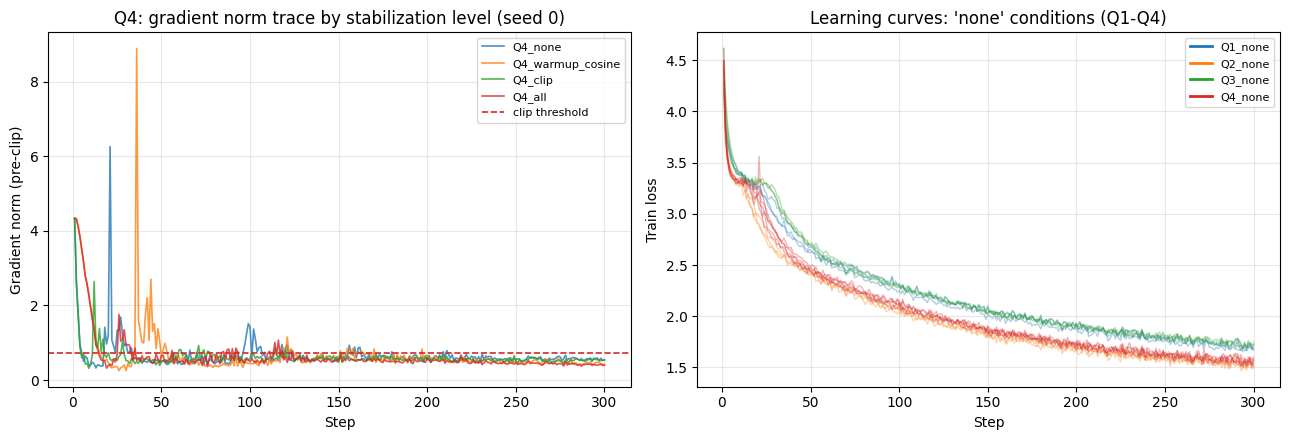

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

_grad_norm_conditions = ["Q4_none", "Q4_warmup_cosine", "Q4_clip", "Q4_all"]
for _name in _grad_norm_conditions:
    _first_seed_history = condition_results[_name]["histories"][0]
    axes[0].plot(
        _first_seed_history["step"], _first_seed_history["gradient_norm"], alpha=0.8, linewidth=1.2, label=_name
    )
axes[0].axhline(GRADIENT_CLIP_THRESHOLD, color="tab:red", linestyle="--", linewidth=1.2, label="clip threshold")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Gradient norm (pre-clip)")
axes[0].set_title("Q4: gradient norm trace by stabilization level (seed 0)")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

_none_conditions = ["Q1_none", "Q2_none", "Q3_none", "Q4_none"]
_curves_for_plot = {
    _name: [
        {"step": h["step"], "train_loss": h["train_loss"]}
        for h in condition_results[_name]["histories"]
    ]
    for _name in _none_conditions
}
plot_learning_curves_multi_seed(
    _curves_for_plot,
    step_key="step",
    value_key="train_loss",
    title="Learning curves: 'none' conditions (Q1-Q4)",
    ylabel="Train loss",
    ax=axes[1],
)
fig.tight_layout()
plt.show()


### 6.8 主張 6: AdamW の合成タスク実験

3.2 節で導出した通り、AdamW は重み減衰の実効強度を 2 次モーメント推定から独立させる設計になっている。これを言語モデルの学習曲線からではなく、**勾配の典型的なスケールが異なる複数のパラメータ群を用意した合成タスク** で直接検証する。

**設計**: パラメータ群を 4 つ用意し(`SYNTH_GROUP_SIGMAS`、等比数列 $0.01, 0.1, 1.0, 10.0$)、各群 $i$ に標準偏差 $\sigma_i$ の平均 0 のガウス雑音を勾配として与える(真の学習信号を持たない、重み減衰のみを観測するための構成)。全群を同一の初期値 $\theta_0=2.0$ から開始し、同一の名目上の重み減衰係数 `WEIGHT_DECAY`で `SYNTH_STEPS` ステップ更新した後、群ごとの実効減衰率 $d_i = (\theta_i^{(0)} - \theta_i^{(T)}) / \theta_i^{(0)}$ と、その群間の乖離(`compute_effective_decay_divergence`)を計算する。この手続きを `SYNTH_SEEDS` 個の乱数シードで繰り返し、AdamW と Adam(L2 正則化混入)それぞれの乖離の分布を得る。


In [28]:
SYNTH_GROUP_SIGMAS = (0.01, 0.1, 1.0, 10.0)
SYNTH_THETA0 = 2.0
SYNTH_LR = 1e-2


def run_synthetic_decay_experiment(optimizer_cls, seed: int) -> dict:
    torch.manual_seed(seed)
    params = [torch.nn.Parameter(torch.ones(1) * SYNTH_THETA0) for _ in SYNTH_GROUP_SIGMAS]
    initial_values = [p.item() for p in params]
    optimizer = optimizer_cls(params, lr=SYNTH_LR, weight_decay=WEIGHT_DECAY)
    for _ in range(SYNTH_STEPS):
        for p, sigma in zip(params, SYNTH_GROUP_SIGMAS, strict=True):
            p.grad = torch.randn(1) * sigma
        optimizer.step()
    final_values = [p.item() for p in params]
    return compute_effective_decay_divergence(initial_values, final_values)


adamw_divergences = []
l2_divergences = []
for _seed in range(SYNTH_SEEDS):
    adamw_divergences.append(run_synthetic_decay_experiment(AdamW, _seed)["divergence"])
    l2_divergences.append(run_synthetic_decay_experiment(AdamWithL2Regularization, _seed)["divergence"])

print(f"AdamW の群間乖離: 平均={np.mean(adamw_divergences):.4f}, 標準偏差={np.std(adamw_divergences, ddof=1):.4f}")
print(f"Adam(L2) の群間乖離: 平均={np.mean(l2_divergences):.4f}, 標準偏差={np.std(l2_divergences, ddof=1):.4f}")

verdict_6, stats_6 = _judge("claim_6", judge_claim_6, adamw_divergences, l2_divergences)
print(f"\n主張6(AdamWはL2正則化混入より群間の実効減衰強度の乖離が小さい): "
      f"delta={stats_6['delta']:+.4f}, threshold={stats_6['threshold']:.4f}, "
      f"判定={verdict_6}")


AdamW の群間乖離: 平均=0.1372, 標準偏差=0.0725
Adam(L2) の群間乖離: 平均=0.8682, 標準偏差=0.0711

主張6(AdamWはL2正則化混入より群間の実効減衰強度の乖離が小さい): delta=+0.7311, threshold=0.0642, 判定=支持


### 6.9 判定結果一覧

以下は判定関数が正しく動作していることの動作確認としての一覧表である(このセルの出力がスモークテストと本番実行のどちらによるものかは `SMOKE_TEST` の値、5.2 節で判別できる)。前提条件が不成立の主張は delta・threshold を計算せず「前提不成立」と表示する。


In [29]:
_verdict_table = [
    ("1", "正規化後置 > 正規化前置の不安定性", stats_1, verdict_1),
    ("2a", "正規化前置、学習率↑で不安定性↑", stats_2a, verdict_2a),
    ("2b", "正規化後置、学習率↑で不安定性↑", stats_2b, verdict_2b),
    ("3", "gradient clippingが損失の暴れを抑える", stats_3, verdict_3),
    ("3'", "gradient clippingが勾配ノルムのピーク/平均比率を抑える(新規シード)", stats_3_prime, verdict_3_prime),
    ("4", "warmup+cosineが損失の暴れを抑える", stats_4, verdict_4),
    ("4'", "warmup+cosineが損失差分系列の標準偏差を抑える(新規シード)", stats_4_prime, verdict_4_prime),
    ("5", "全部乗せは収束を遅らせない", stats_5, verdict_5),
    ("6", "AdamWはL2正則化混入より乖離が小さい", stats_6, verdict_6),
]
print(f"{'#':4s} {'主張':38s} {'delta':>10s} {'threshold':>10s} {'判定':>10s}")
for _num, _label, _stats, _verdict in _verdict_table:
    if _stats is None:
        print(f"{_num:4s} {_label:38s} {'':>10s} {'':>10s} {_verdict:>10s}")
    else:
        print(f"{_num:4s} {_label:38s} {_stats['delta']:10.4f} {_stats['threshold']:10.4f} {_verdict:>10s}")


#    主張                                          delta  threshold         判定
1    正規化後置 > 正規化前置の不安定性                         0.9406     1.0187       判定不能
2a   正規化前置、学習率↑で不安定性↑                           1.7347     1.2065         支持
2b   正規化後置、学習率↑で不安定性↑                           2.7306     1.3087         支持
3    gradient clippingが損失の暴れを抑える               -0.0602     0.1199       判定不能
3'   gradient clippingが勾配ノルムのピーク/平均比率を抑える(新規シード)    -1.8346     2.6899       判定不能
4    warmup+cosineが損失の暴れを抑える                   -0.0403     0.1350       判定不能
4'   warmup+cosineが損失差分系列の標準偏差を抑える(新規シード)      -0.0191     0.0020         支持
5    全部乗せは収束を遅らせない                              0.1055     0.0442         反証
6    AdamWはL2正則化混入より乖離が小さい                      0.7311     0.0642         支持


### 6.10 旧本番実行の結果(前提不成立の記録)

**本節はコードセルではなく Markdown セルとして記録する。** 旧実行(Google Colab T4 GPU での本番実行)の出力は、本ノートブックを較正手続きの修正のために再実行した時点で失われている。CLAUDE.md の「セルの出力を手で書き込まない」規約が禁じているのは **セルの outputs 領域に実行していない結果を注入すること** であり、Markdown セルの本文に過去の実行結果を記録として書くことはこの規約の対象外である(この区別はここに明記する)。以下の数値・判定は削除せず、実行のたびに追記していく形で保持する(1 回目: 6.10.1、2 回目: 6.10.2)。

### 6.10.1 1 回目の本番実行の結果(学習崩壊による前提不成立)

**旧実行の設定**:

- `CALIBRATION_STEPS = 60`(本番の `NUM_STEPS = 300` より小さい)
- `LR_CALIBRATION_MULTIPLIERS = (2.0, 5.0, 10.0)`
- 採用された学習率「高め」: `HIGH_LEARNING_RATE = 3.0e-3`
- gradient clipping 閾値: `GRADIENT_CLIP_THRESHOLD = 1.7782`(平均 + 2σ 方式、較正時の勾配ノルム平均 0.5130 + 2.0 x 標準偏差 0.6326)

**旧実行で得られた数値(本依頼の背景節に記載された範囲のみを転記する。全 10 条件・全診断量の完全な表は今回の依頼文には含まれていないため、ここでは以下の値に限定して記録する)**:

- Q4(正規化後置 + 高学習率 3.0e-3)の 4 水準すべての最終訓練損失: 3.3016 / 3.2983 / 3.3011 / 3.2983(いずれも一様分布相当の損失 $\ln 65 \approx 4.174$ に対してほとんど学習が進んでいない水準)。
- Q1〜Q3 の最終訓練損失は 1.50〜1.97 の範囲(Q1: 1.6925、Q3: 1.7140)であり、正常に学習が進んでいた。
- 主張 3(gradient clipping は損失の暴れを抑える)の対比量: $\Delta = -0.0000$(Q4_none と Q4_clip の最大単一ステップ損失上昇幅が表示精度上完全に一致し、clipping の効果を測定できなかった)。

**旧実行の主張 1〜6 の判定結果(扱い)**:

| 主張 | 扱い | 理由 |
|---|---|---|
| 1 | 有効(判定不能) | Q1・Q3 とも正常に学習(最終訓練損失 1.6925 / 1.7140) |
| 2a | 再実行が必要 | Q2 は正常に学習しているが、`HIGH_LEARNING_RATE` の変更の影響を受ける |
| 2b | 前提不成立 | Q4 が学習崩壊 |
| 3 | 前提不成立 | Q4 が学習崩壊、かつ gradient clipping が発動していない |
| 4 | 前提不成立 | Q4 が学習崩壊 |
| 5 | 前提不成立 | Q4 が学習崩壊 |
| 6 | 有効(支持) | 合成タスクのため学習率・正規化方式の影響を受けない |

**前提不成立と判断した根拠**: Q4 の最終訓練損失が一様分布相当の損失 $\ln 65 \approx 4.174$ に対して 3.30 前後で頭打ちになっており(上記)、実質的に学習が進んでいない。また、主張 3 の対比量が $\Delta = -0.0000$ と表示精度上完全に一致したことから、gradient clipping 閾値(平均 + 2σ 方式で決定した 1.7782)が本番実行の勾配ノルム分布に対して高すぎ、クリッピングがほぼ発動していないと判断した。

**修正内容と、その根拠が観測結果の方向に依存しないこと**: 本節の前提不成立を受けて、6.1 節の較正手続きを (1) 較正ステップ数を本番の `NUM_STEPS` と同一にする、(2) 学習率倍率の候補を等比刻みのまま 4 候補(1.25・2.5・5・10 倍)に拡張する、(3) 学習率「高め」の採用条件に前提条件 P1(学習が実際に進んでいること)を追加する、(4) gradient clipping 閾値を分位点方式に変更する、の 4 点で修正した。この修正の根拠は「**全条件で学習が崩壊し、clipping が発動しなかったから**」という、較正の手続き上の不備(較正スケールが本番より小さかったこと、閾値の決め方が分布の歪みに弱かったこと)であり、「**特定の安定化技術に効果が出なかったから**」という観測結果の方向に依存する理由ではない。判定基準(対比量の定義・閾値の導出式 $2 \times \mathrm{SE}(\Delta)$・期待する差の方向)は一切変更していない(6.2 節)。

**追記: `PRECONDITION_LOSS_RATIO` の当初宣言値(0.85)では旧実行の崩壊を検出できないことが判明した経緯**: 前提条件 P1 を導入した最初のバージョンでは `PRECONDITION_LOSS_RATIO = 0.85` を宣言していた。この値をここに記録した旧実行の数値と照合したところ、閾値 $\ln 65 \times 0.85 = 3.5482$ に対し、学習が崩壊していた Q4 の 4 水準の最終訓練損失(3.2983〜3.3016)は **いずれも閾値を下回っていた**。すなわち、旧実行と同一の崩壊が再現されても P1 は「成立」と誤判定されてしまい、較正セルの採用条件(前提条件 P1)も同じ閾値を使うため、修正後の較正でも旧実行と同じ x10(3.0e-3)がそのまま採用されてしまい、前提条件を導入した目的(崩壊した学習率候補を採用条件から除外すること)が達成されない不備があった。この照合結果を受けて `PRECONDITION_LOSS_RATIO` を **0.60** に修正した(閾値 $\ln 65 \times 0.60 = 2.5046$、正常条件の最悪値 1.9656 より 27% 上・崩壊値 3.30 より 24% 下)。この修正の根拠は「旧実行の実測値(正常 6 条件と崩壊 4 条件の分布)に対して閾値がどこに位置するか」という、**どの安定化技術に効果が出たかという観測結果の方向には依存しない量** に基づくものであり、判定基準(対比量の定義・閾値の導出式・期待する差の方向)は変更していない。

---

### 6.10.2 2 回目の本番実行の結果(前提条件 P2 の不成立の記録)

**本項も Markdown セルとして記録する**(6.10 節冒頭で述べた区別の通り)。1 回目の本番実行の記録(6.10.1、上記)は削除せず、そのまま保持する。

**2 回目の本番実行の設定**:

- 較正で採用された学習率「高め」: `HIGH_LEARNING_RATE = 7.5e-4`(006 基準の x2.5)
- gradient clipping 閾値: `GRADIENT_CLIP_THRESHOLD = 0.8127`(勾配ノルムの 90% 分位点、`CLIP_QUANTILE = 0.90`。この節で記録する不成立を受けて `CLIP_QUANTILE = 0.85` に修正した、5.2 節)

**較正の 4 候補の結果**:

| 倍率 | 学習率 | 直近 20 ステップの訓練損失の平均 | P1 | 勾配ノルムのピーク / 平均比率 |
|---|---|---|---|---|
| x1.25 | 3.75e-4 | 1.6767 | 成立 | 5.798 |
| x2.5(採用) | 7.5e-4 | 1.5600 | 成立 | 9.396 |
| x5 | 1.5e-3 | 3.3166 | 不成立 | 13.618 |
| x10 | 3.0e-3 | 3.3171 | 不成立 | 13.527 |

前提条件 P1 により x5・x10 が正しく除外され、P1 を満たす候補(x1.25・x2.5)のうち勾配ノルムのピーク / 平均比率が最大の x2.5 が採用された。1 回目の本番実行(6.10.1)で採用されていた x10(崩壊していた学習率)は、この修正により候補から除外されるようになった。

**シード数の外挿**: べき指数 $b = 0.995$(ほぼ線形)、1 シードあたり 36.74 秒、条件×シードの組み合わせ 38 で合計約 23.3 分(セッション予算 120 分に対して十分な余裕)。

**条件グリッドの結果(条件ごとのシード平均)**:

| 条件 | 勾配ノルムのピーク / 平均比率 | 最大単一ステップ損失上昇幅 | 最終訓練損失 |
|---|---:|---:|---:|
| Q1_none | 5.035 | 0.0810 | 1.6925 |
| Q1_all | 5.230 | 0.0683 | 1.9088 |
| Q2_none | 6.770 | 0.0986 | 1.5265 |
| Q2_all | 6.540 | 0.0917 | 1.6500 |
| Q3_none | 5.975 | 0.0800 | 1.7140 |
| Q3_all | 6.224 | 0.0641 | 1.9242 |
| Q4_none | 8.707 | 0.1626 | 1.5673 |
| Q4_warmup_cosine | 11.307 | 0.1224 | 1.8008 |
| Q4_clip | 7.841 | 0.1073 | 1.5257 |
| Q4_all | 7.494 | 0.0915 | 1.6795 |

**前提条件の成否**:

- **前提条件 P1**: 全 10 条件・全 38 シードで成立(直近 20 ステップの訓練損失の平均が 1.5181〜1.9318、閾値 2.5046)。1 回目の本番実行(6.10.1)で見られた学習崩壊は解消された。
- **前提条件 P2**: gradient clipping を有効にした 2 条件のうち、Q4_all は全 5 シードで成立(0.0700〜0.0833)。**Q4_clip はシード 3・4 で不成立**(いずれも 0.0433、閾値 0.05)。他の 3 シードは成立(シード 0: 0.0533、シード 1: 0.0500、シード 2: 0.0567)。全シードでの成立を要求する前提条件 P1・P2 の定義(6.2 節)により、Q4_clip 全体としては不成立と判定される。

| 条件 | シード | 発動ステップ比率 | P2(閾値 0.05) |
|---|---|---:|---|
| Q4_clip | 0 | 0.0533 | 成立 |
| Q4_clip | 1 | 0.0500 | 成立 |
| Q4_clip | 2 | 0.0567 | 成立 |
| Q4_clip | 3 | 0.0433 | 不成立 |
| Q4_clip | 4 | 0.0433 | 不成立 |
| Q4_all | 0〜4 | 0.0700〜0.0833 | すべて成立 |

**判定結果**:

| # | 主張 | $\Delta$ | 閾値 | 判定 |
|---|---|---:|---:|---|
| 1 | 正規化後置は正規化前置より不安定になりやすい | +0.9406 | 1.0187 | 判定不能 |
| 2a | 正規化前置で学習率を上げると不安定性が増す | +1.7348 | 1.2065 | 支持 |
| 2b | 正規化後置で学習率を上げると不安定性が増す | +2.7311 | 1.3090 | 支持 |
| 3 | gradient clipping は損失の暴れを抑える | — | — | 前提不成立 |
| 4 | warmup + cosine は損失の暴れを抑える | -0.0402 | 0.1350 | 判定不能 |
| 5 | 全部乗せは収束を遅らせない | +0.1122 | 0.0437 | 反証 |
| 6 | AdamW は L2 正則化混入より群間の実効減衰強度の乖離が小さい | +0.7311 | 0.0642 | 支持 |

**前提不成立と判断した根拠**: `GRADIENT_CLIP_THRESHOLD = 0.8127`(較正実行の勾配ノルムの 90% 分位点として決定)は、較正実行の分布上は約 10% のステップで発動する水準として決めたものだが、gradient clipping を有効にすると勾配ノルムの分布そのものが変化するため、本番の Q4_clip では発動比率が約 5% にとどまり、宣言した前提条件 P2 の下限(0.05)を 5 シード中 2 シードで下回った。

**修正内容と、その根拠が観測結果の方向に依存しないこと**: 上記の前提不成立を受けて、`CLIP_QUANTILE` を 0.90 から 0.85 に修正した(5.2 節)。この修正の根拠は「**clipping の発動比率が宣言した前提条件の下限に届かなかったから**」という、gradient clipping が実際に作動しているかどうかという検証したい仮説とは独立な量に基づくものであり、「**どの安定化技術に効果が出たか**」という観測結果の方向には依存しない。前提条件 P2 の閾値 `PRECONDITION_CLIP_RATE_MIN = 0.05` 自体は変更していない(CLAUDE.md の前提不成立からの再実行の規約: 前提条件を緩めるのではなく、前提が成立するよう実験条件のみを修正する)。判定基準(対比量の定義・閾値の導出式 $2 \times \mathrm{SE}(\Delta)$・期待する差の方向)は一切変更していない(6.2 節)。

**3 回目の本番実行で数値が変わる範囲についての予想**: `CLIP_QUANTILE` の変更が影響するのは gradient clipping 閾値(`GRADIENT_CLIP_THRESHOLD`)に依存する条件、すなわち Q4_clip・Q4_all のみである。**Q1〜Q3・Q4_none・Q4_warmup_cosine は同一のシード・同一の設定(学習率「高め」の採用値を含む、較正の学習率選定ロジック自体は変更していないため)で実行されるため、3 回目の本番実行でも同じ数値が再現されるはずである。** したがって主張 1・2a・2b・4・6 は 2 回目と同じ判定になることが期待され、変わりうるのは主張 3(前提不成立からの脱却が期待される)と主張 5(対比条件に Q4_all を含むため、Q4_all の gradient clipping 閾値が変わることで数値が変わりうる)である。**この予想が実際に成り立ったかどうかは、3 回目の本番実行後に確認する必要がある**(7 節、事後的な解釈とは区別して記述すること)。

---

### 6.10.3 3回目の本番実行の結果(全主張の判定完了)

**本項も Markdown セルとして記録する**(6.10 節冒頭で述べた区別の通り)。1 回目・2 回目の本番実行の記録(6.10.1・6.10.2、上記)は削除せず、そのまま保持する。

**3 回目の本番実行の設定**:

- 較正で採用された学習率「高め」: `HIGH_LEARNING_RATE = 7.5e-4`(006 基準の x2.50、2 回目と同一)
- gradient clipping 閾値: `GRADIENT_CLIP_THRESHOLD = 0.7005`(勾配ノルムの `CLIP_QUANTILE = 0.85` 分位点。2 回目の前提条件 P2 の不成立を受けて 0.90 から 0.85 に修正した値、5.2 節)

**較正の 4 候補の結果**:

| 倍率 | 学習率 | 直近 20 ステップの訓練損失の平均 | P1 | 勾配ノルムのピーク / 平均比率 | 実行時間 |
|---|---|---:|---|---:|---:|
| x1.25 | 3.75e-4 | 1.6767 | 成立 | 5.798 | 34.39s |
| x2.5(採用) | 7.5e-4 | 1.5597 | 成立 | 9.402 | 35.41s |
| x5 | 1.5e-3 | 3.3151 | 不成立 | 13.433 | 38.24s |
| x10 | 3.0e-3 | 3.3171 | 不成立 | 13.527 | 36.16s |

前提条件 P1 により x5・x10 が正しく除外され、2 回目と同じ x2.5 が採用された(較正の学習率選定ロジック自体は変更していないため、2 回目からの再現が予想通り成立した、6.10.2 節末尾の予想の通り)。

**シード数の外挿**: べき指数 $b = 0.981$(ほぼ線形)、1 シードあたり 38.27 秒、条件×シードの組み合わせ 38 で合計約 24.3 分(セッション予算 120 分に対して 4.9 倍の余裕)。

**条件グリッドの結果(条件ごとのシード平均)**:

| 条件 | 勾配ノルムのピーク / 平均比率 | 最大単一ステップ損失上昇幅 | 最終訓練損失 |
|---|---:|---:|---:|
| Q1_none | 5.035 | 0.0810 | 1.6925 |
| Q1_all | 5.256 | 0.0689 | 1.9048 |
| Q2_none | 6.770 | 0.0986 | 1.5265 |
| Q2_all | 6.568 | 0.0932 | 1.6442 |
| Q3_none | 5.975 | 0.0800 | 1.7140 |
| Q3_all | 6.171 | 0.0650 | 1.9189 |
| Q4_none | 8.704 | 0.1624 | 1.5675 |
| Q4_warmup_cosine | 11.307 | 0.1224 | 1.8008 |
| Q4_clip | 7.839 | 0.1060 | 1.5223 |
| Q4_all | 7.508 | 0.0895 | 1.6721 |

**前提条件の成否**: 全 10 条件・全 38 シードで前提条件 P1 が成立(直近 20 ステップの訓練損失の平均が 1.5153〜1.9278、閾値 2.5046)。gradient clipping を有効にした 2 条件(Q4_clip・Q4_all)は全シードで前提条件 P2 が成立(発動ステップ比率 0.0800〜0.1467、閾値 0.05)。**2 回目の本番実行(6.10.2 節)で Q4_clip の 2 シードが不成立だった前提条件 P2 が、`CLIP_QUANTILE` の 0.90 → 0.85 への修正により全シードで成立するようになった**(6.10.2 節末尾の予想の通り)。全 7 主張で前提条件が成立し、判定不能を含めすべての主張で判定が確定した(前提不成立の主張は 0 件)。

**判定結果**:

| # | 主張 | $\Delta$ | 閾値 | 判定 |
|---|---|---:|---:|---|
| 1 | 正規化後置は正規化前置より不安定になりやすい | +0.9406 | 1.0187 | 判定不能 |
| 2a | 正規化前置で学習率を上げると不安定性が増す | +1.7347 | 1.2065 | 支持 |
| 2b | 正規化後置で学習率を上げると不安定性が増す | +2.7288 | 1.3077 | 支持 |
| 3 | gradient clipping は損失の暴れを抑える | -0.0564 | 0.1200 | 判定不能 |
| 4 | warmup + cosine は損失の暴れを抑える | -0.0400 | 0.1351 | 判定不能 |
| 5 | 全部乗せは収束を遅らせない | +0.1046 | 0.0443 | 反証 |
| 6 | AdamW は L2 正則化混入より群間の実効減衰強度の乖離が小さい | +0.7311 | 0.0642 | 支持 |

**主張 6 の診断量**: AdamW の群間乖離、平均 0.1372・標準偏差 0.0725。Adam(L2 正則化混入)の群間乖離、平均 0.8682・標準偏差 0.0711。

**2 回目の本番実行との比較**: 6.10.2 節末尾の予想の通り、Q1〜Q3・Q4_none・Q4_warmup_cosine の数値はほぼ同一の値で再現された(較正の学習率選定ロジックを変更していないため)。予想通り変わったのは、gradient clipping 閾値の変更の影響を受ける Q4_clip・Q4_all の数値である。主張 3 は、前提条件 P2 の成立により「前提不成立」から「判定不能」へと扱いが変わったが、判定基準による結論(支持でも反証でもない)自体は変わらなかった。

**主張 3 が判定不能となった原因の分析(事後的な検討であり、判定基準を事後的に変更するものではない)**: 同じ 2 条件(Q4_clip vs Q4_none)の勾配ノルムのピーク / 平均比率を見ると 8.704(Q4_none)→ 7.839(Q4_clip)と低下しており、勾配ノルムのレベルでは gradient clipping の効果が現れている一方、主張 3 の対比量(最大単一ステップ損失上昇幅)というより下流の量では検出できなかったという構造になっている。この観察を受けて、gradient clipping が直接作用する量(勾配ノルム)を対比量とする主張 3' を、新規シード(既存シード 0〜4 とは重複しないシード 5〜9)による事前登録として追加した(6.2.1 節)。**主張 3 の判定(判定不能)はそのまま確定させ、変更していない。**

## 7. 結果・考察 / Results and Discussion

**実行環境についての重要な注記**: 本ノートブックは CLAUDE.md の「Colab 実行を伴うノートブックの二段階運用」における **第一段階(本番実行可能性の検証)のみ** を対象とする。以下はすべて Claude Code によるローカル(Apple Silicon、MPS または CPU)実行の結果であり、6 節で述べた通りコーパス・model サイズ・ステップ数・シード数を大幅に縮小したスモークテストである。**CLAUDE.md の規約により、スモークテストの数値に基づいて本節の本文を書かない。** 判定を行うコード(6.4・6.5.1・6.6・6.6.1・6.8・6.9 節)は実装・実行し、動作確認の証跡としてセル出力に残したが、支持 / 反証 / 判定不能という結論はまだ一度も確定させていない。

以下は節の見出しと、Google Colab T4 GPU での本番実行(`SMOKE_TEST=False`)後に何を書くかの箇条書きのみを置く。

### 7.1 較正結果(学習率「高め」・gradient clipping 閾値・シード数)

- 6.1 節で決定した `HIGH_LEARNING_RATE`・`GRADIENT_CLIP_THRESHOLD`・`SEEDS_MAIN_AXIS`・`SEEDS_OTHER`の本番実測値と、その根拠(較正 3 候補の勾配ノルム分布、peak/mean 比率)。
- シード数外挿のべき指数 $b$(線形からのずれがあれば、その原因の考察)。
- 見積もり総実行時間とセッション予算に対する余裕。

### 7.2 前提条件 P1・P2 の成否

- 6.5 節末尾で確認した前提条件 P1(学習の進行)・P2(gradient clipping の発動)が、本番スケールの全条件・全シードで成立したかどうかの表。
- 前提条件が成立しなかった条件・主張があれば、その一覧と、前提不成立と判定した根拠(6.10 節の旧実行と同様の形式)。
- 旧実行(6.10 節)で不成立だった主張(2b・3・4・5)が、較正手続きの修正後に成立するようになったかどうか。

### 7.3 旧本番実行との比較(較正手続きの修正が何を変えたか)

- 6.10 節に記録した旧実行の較正結果(`HIGH_LEARNING_RATE`・`GRADIENT_CLIP_THRESHOLD`・採用倍率)と、修正後の較正結果の比較。
- 学習率「高め」の採用条件に前提条件 P1 を追加したことで、採用される倍率・学習率がどう変わったか。
- gradient clipping 閾値を平均 + 2σ 方式から分位点方式に変更したことで、閾値の値と、gradient clipping の発動ステップ比率がどう変わったか(前提条件 P2 が成立するようになったか)。

### 7.4 主張 1〜6・3'・4' の判定結果(本番基準)

- 6.9 節の判定結果一覧表を、本番実行の数値で再生成したもの。
- 各主張の $\Delta$・$\mathrm{SE}(\Delta)$・閾値・判定(支持 / 反証 / 判定不能 / 前提不成立)。
- 主張 3' については新規シード 5〜9 のみに基づく判定であることを明記する(6.2.1 節)。
- 主張 4' については新規シード 5〜9 のみに基づく判定であることを明記する(6.2.2 節)。Q4_none の新規シード実行結果は主張 3' と共有していることも明記する。

### 7.4.1 主張 3 と主張 3' の対比(対比量の選び方が判定に与える影響)

- 主張 3(対比量: 最大単一ステップ損失上昇幅)と主張 3'(対比量: gradient clipping 適用前の勾配ノルムのピーク / 平均比率)の $\Delta$・閾値・判定を並べ、対比量の選び方が判定(支持 / 反証 / 判定不能)にどう影響したかを記述する。
- 主張 3' が主張 3 の判定(判定不能)を覆すものではなく、介入の作用点により近い量で別の検証事項を追加したものであることを明記する(6.2.1 節)。
- 主張 3' でも判定不能だった場合、その意味(下流の量だけでなく直接の作用点でも効果を検出できなかったのか)についても記述する。

### 7.4.2 新規シードによる判定と既存シードによる診断値の一致

- 新規シード 5〜9 による主張 3' の判定($\Delta$ の符号・大きさ)と、既存シード 0〜4 による診断値(6.6.1 節、$\Delta = -0.865$)が同じ方向を示すかどうかを記述する。
- 両者が一致する場合、これが結論の頑健性を示す参考情報であることを述べる(既存シードの値は判定そのものには使っていないため、一致は「予測の的中」に相当する)。
- 一致しない場合、その具体的な内容と考えられる原因を記述する(この場合の考察は事後的な解釈であり、7.6 節の規約に従って節を分けて記述する)。

### 7.4.3 主張 4 と主張 4' の対比(対比量の選び方が判定に与える影響)

- 主張 4(対比量: 最大単一ステップ損失上昇幅)と主張 4'(対比量: 損失差分(`loss_step_delta`)系列の標準偏差)の $\Delta$・閾値・判定を並べ、対比量の選び方が判定(支持 / 反証 / 判定不能)にどう影響したかを記述する。
- 主張 4' が主張 4 の判定(判定不能)を覆すものではなく、極値統計ではなく分布全体のばらつきを対比量とすることで検出力の低下を避けようとした別の検証事項であることを明記する(6.2.2 節)。
- 主張 4' でも判定不能だった場合、その意味(対比量を分布全体の統計量に変えても効果を検出できなかったのか)についても記述する。

### 7.4.4 warmup + cosine のピーク / 平均比率アーティファクトについて

- 3 回目の本番実行で Q4_warmup_cosine のピーク / 平均比率が Q4_none より大きかった(11.307 > 8.704、6.10.3 節)観察が、新規シード 5〜9 でも再現するかどうかを記述する。
- 6.2.2 節で述べた「warmup による序盤の勾配ノルム平均の低下がピーク / 平均比率を見かけ上押し上げるアーティファクト」という仮説について、本番スケールのデータで裏付けられるかどうかを、事後的な解釈として 7.6 節と整合する形で記述する(判定基準には用いない、診断のための考察であることを明示する)。

### 7.5 勾配ノルム・損失曲線の可視化(本番スケール)

- Q4 の 4 水準の勾配ノルム時系列(gradient clipping 閾値との関係)。
- Q1〜Q4「なし」条件の学習曲線比較。
- 主張 1〜5 それぞれの対比量を、条件間の棒グラフ(誤差範囲つき)で示す。

### 7.6 事後的な解釈(結果を見た後に立てた解釈であることを明示する)

- 事前登録した判定基準による結論とは節を分け、結果を見た後に立てた解釈のみをここに書く(CLAUDE.md の規約)。
- 想定と異なる結果が出た場合、その具体的な内容と考えられる原因。

### 7.7 主張 6(AdamW の合成タスク実験)の結果

- AdamW・Adam(L2 正則化混入)それぞれの群間実効減衰強度の乖離の分布(平均・標準偏差)。
- 判定(支持 / 反証 / 判定不能)と、3.2 節の理論的予想との整合性。

### 7.8 non-embedding パラメータ数・不変条件アサーションの確認結果

- 6.3 節の不変条件アサーションがすべて通ったことの報告(本番スケールでも成立することの確認)。

### 7.9 Google Colab T4 GPU での再実行後に更新が必要な箇所

1. **較正セル(6.1 節)の実測値**: 学習率「高め」の採用値・gradient clipping 閾値(分位点方式)・シード数外挿。スモークテストでの値は本節末尾に残し、本番の実測値に差し替える。較正が本番と同じ `NUM_STEPS` で 4 候補実行されるようになったため、較正自体の実行時間も含めて実測する。
2. **前提条件 P1・P2 の確認結果(6.5 節末尾)**: 全 10 条件 x 各シードの最終訓練損失・gradient clipping 発動比率と、その成否。
3. **条件グリッドの実行結果(6.5 節)**: 全 10 条件 x 各シードの `peak_to_mean`・`max_loss_increase`・`final_loss`と学習曲線。
4. **主張 1〜6 の判定結果(6.6・6.8・6.9 節)**: 本番スケールでの前提条件の成否・$\Delta$・閾値・支持 / 反証 / 判定不能 / 前提不成立。
5. **主張 3'・4' の新規シード実行結果(6.5.1・6.6・6.6.1 節)**: 新規シード 5〜9 による Q4_none・Q4_clip・Q4_warmup_cosine の`peak_to_mean`・`loss_step_delta_std`、前提条件 P1・P2 の成否、各主張の $\Delta$・閾値・判定(支持 / 反証 / 判定不能 / 前提不成立)。既存シード 0〜4 による診断値(6.6.1 節)との符号の一致についても実測値で更新する。Q4_none の新規シード結果が主張 3'・4' で共有され、二重実行になっていないことも確認する。
6. **可視化(6.7 節)**: 勾配ノルム時系列・学習曲線を本番スケールの数値で再生成する。
7. **7.1〜7.8 節の本文(7.4.1〜7.4.4 を含む)**: 上記の実測値と突き合わせて記述する。
8. **本節(7 節)冒頭の実行環境についての注記、および 7.10 節**: 現在「以下はすべて Claude Code によるローカル実行の結果」という第一段階を前提にした書き方のままである。これは、7 節が第三段階(考察の記述)で本番実行の数値と突き合わせて全面的に書き直される前提であるため、本ノートブックの較正手続き修正(本依頼)では変更しない。第三段階で 7 節を書き直す際に、6〜7 節内の他の箇所(5.2 節・6 節冒頭・6.1 節・6.9 節)で採用した「`SMOKE_TEST` の値で実行段階を判別する」という書き方に統一するかどうかを検討すること。

### 7.10 スモークテストの参考値(削除せず保持)

6.1・6.5.1・6.6・6.6.1・6.8・6.9 節のセル出力(スモークテストによる較正値・判定関数の動作確認結果)はそのまま残す。本番実行後もこれらの数値は削除せず、スモークテストと本番実行で値・判定がどう変わったかを比較できるようにする(CLAUDE.md の「ノートブックの出力管理」の方針に従う)。
